# 감성 분석 모델 구현을 통한 on-device 환경의 이해

과제식별: [스프린트 미션13](https://www.codeit.kr/topics/studyGroupStep6985c09890c7e12606322e2e/lessons/13997)  
변경사항: [미션 수정 내용](https://aiota.notion.site/Parameter-Efficient-Fine-Tuning-343dc3286bf18057abecca0a3d80fb19)  
작성 : 2026.06.08 신호정

## A. 프로젝트의 목적

쇼핑몰 리뷰 데이터를 대상으로 감성 분석을 수행하는 모델을 제작합니다.  
모델은 BERT 계열을 사용하며, 최소 2개 이상의 모델을 대상으로 합니다.  
모델 학습 시의 방법을 Full Fine-Tuning, Freeze, PEFT 방식을 각각 적용합니다.  
학습 시간, 같은 학습 조건에서의 감성 분석 정확도, 최종 저장 모델의 용량 등을 비교합니다.  
2개의 후보 모델 중 가장 좋은 모델을 선별 후 모바일에서 간이 감성 분석 모델의 작동을 확인합니다.

### A-a. 프로젝트 수행방향

on-device에 적절한 BERT 기반 모델을 탐색하고 2종 선발합니다.  
쇼핑몰 리뷰 데이터 구성을 확인하고 및 데이터 사이즈에 따른 학습 전략 결정합니다.  
Full Fine-Tuning, Freeze, PEFT 학습 방법의 차이점을 정리하고 구현 계획을 수립합니다.  
선발된 모델의 학습 파이프라인 구축하고 타당성을 검증합니다.  
모델 학습을 수행하고 체크 포인트 저장합니다.  
학습된 개별 모델의 평가 지표를 산출하고 출력물을 비교하여 on-device로 이식할 모델을 결정합니다.  
최적 모델을 ONNX 변환합니다.  
Unity Sentis 를 통한 모델 이식을 진행하고, UX를 포함한 시스템 통합 작업을 수행합니다.  
Android APK 빌드하여 설치 후 작동을 확인합니다.

### A-b. 프로젝트 수행계획

1. on-device에 적합한 경량화된 BERT 기반 모델을 탐색합니다.  
탐색된 모델에서 용량, 정확도, 처리속도 순으로 우선순위를 두고 2개의 모델을 선발합니다.  

2. 쇼핑몰 리뷰 데이터의 파일 경로 별 구성, 수량, 스키마의 형태와 일치 여부를 조사합니다.  

3. 각각의 테이블을 DataFrame으로 읽은 후에 아래의 분석을 수행후 전처리를 수행합니다.  
    - 카테고리 컬럼이 있는지 확인하고, 없으면 파일별 출처 컬럼을 부여
    - 데이터 규모, 길이
    - 어휘 분포
    - 라벨 분포를 통해 클래스 불균형 파악
    - 결측/중복 비율
    - NFKC 정규화, 중복 제거, 길이 필터링, 제어문자 제거

4. 전처리가 끝난 후에 8 : 1.5 : 0.5 의 비율로 train, valid, test 로 테이블을 재분배합니다.  
    - stratified split 으로 라벨 비율을 유지
    - 재현성을 위해 random_state 고정 처리 진행

5. 모델 별 데이터 셋을 구현합니다.  
    - 토크나이저는 모델 사전학습 vocab을 그대로 사용

6. 선별된 모델을 ipynb 런타임으로 불러옵니다.  

7. Full Fine-Tuning, Freeze, Lora-PEFT을 충족하는 훈련 프로세스를 구현합니다.  
    - 세 방식 모두 transformers.Trainer 를 공통 학습기로 사용합니다.
    - LoRA-PEFT는 PEFT 라이브러리의 get_peft_model 로 모델을 래핑하여 학습기에 투입

8. 모델과 훈련 별 적절한 하이퍼파라미터를 설정합니다.  
    - seed, batch_size, max_seq_len, optimizer, warmup ratio 는 공통값으로 고정

9. 각각의 훈련기로 모델 학습을 수행하며 진행에 따른 메트릭도 출력하고 적절한 step 마다 checkpoint 를 저장합니다.
    - ONNX export를 고려하여 평가/추출 시점에서는 아래의 사항을 적용하여 저장합니다.
        - model.eval() 모드
        - dropout 비활성
        - 동적 플로우를 회피하는 형태

10. 학습이 완료된 훈련기에 측정된 평가로그를 통해 손실과 정확도 등을 그래프로 표기합니다.  
    - macro-F1 을 적용

11. 모델, 훈련 별로 분류된 최종 학습 모델 pt 파일을 가지고 종합 평가 지표를 측정합니다.

12. 종합 평가 지표 중 용량, 정확도, 처리순서 순으로 우선 순위를 두고 가장 좋은 모델을 선택합니다.

13. 최적 모델을 파이토치의 onnx.export 및 사전처리를 통해 ONNX 포멧으로 변환합니다.(Fixed Shape 로 모바일 최적화)  
    - Lora-PEFT의 경우 Lora 계층 가중치를 merge_and_unload를 통해 기존 모델에 통합하는 과정을 선행

14. 변환된 ONNX 포멧을 아래와 같이 검증합니다.
    - onnx.checker.check_model 함수를 통해 구조 검증
    - onnxruntime 패키지를 통해 런타임 작동 검증
        - np.allclose, atol=1e-4 옵션을 반영하여 출력 수치 일치를 확인합니다.  

15. Unity 6.3 LTS (6000.3.17f1) 버전을 통한 ONNX 시스템 통합 작업을 수행합니다.  
    - ONNX Import
    - AI Worker 구현
    - 런타임 로드 및 Backend 설정
    - Unity Sentis의 토크나이저가 호환되지 않을 시, C# 기반 토크나이저 구현
    - Unity 쪽의 토크나이저와 기존 사전학습 토크나이저의 작동 일치 확인

16. Unity Engine을 통해 어플리케이션 구현을 진행합니다.  
    - 서비스 로직 제작
    - UI 제작

17. Android OS 13 버전 기준으로 APK를 빌드합니다.  

18. 테스트 폰(Galaxy S25)에 설치하여 테스트를 진행하고 이슈를 수정합니다.  

19. 이슈 사항을 해결 후 시연 영상을 촬영하여 첨부하고, 완성된 APK를 백업 후 필요에 따라 배포합니다.  

### A-c. 추가 고려 사항
1. 학습이 작동하는 환경은 Colab L4 입니다.
    - 따라서 런타임이 중단될 경우에 대비한 백업 처리가 항상 이루어져야 합니다.

2. Colab L4 런타임 상에서 CheckPoint가 저장되는 곳은 Google Drive 입니다.
    - 학습 파이프라인 가동 전에 파일 저장 경로가 Google Drive를 바라보고 있는지 명시적으로 확인합니다.

3. ipynb의 작성과 작동을 검증하는 환경은 WSL2, RTX 5050 Laptop 인 로컬 환경입니다.  

4. 로컬에서 검증이 다된 ipynb 파일을 colab에서 학습시킵니다.  
    - 따라서 is_colab flag를 전역적으로 두어, 로컬 or colab에 맞는 작동을 하도록 셀 별 분기를 설정해야 합니다.

5. Random Seed 는 42로 고정하여 전역 적용한다.

6. 시각화 한글 폰트는 NanumGothic 을 사용한다.

### A-d. 전역 설정

In [ ]:
from pathlib import Path

# Colab/로컬 실행 환경 플래그 — Colab 업로드 시 True로 변경
is_colab = False

if is_colab:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive 마운트 완료')
else:
    print('로컬 환경으로 실행 중')

DATA_ROOT = Path('/content/drive/MyDrive/mission13/DataTable') if is_colab else Path('./DataTable')
SAVE_ROOT = Path('/content/drive/MyDrive/mission13') if is_colab else Path('.')

print(f'DATA_ROOT : {DATA_ROOT}')
print(f'SAVE_ROOT : {SAVE_ROOT}')

로컬 환경으로 실행 중
DATA_ROOT : DataTable
SAVE_ROOT : .


In [ ]:
import random
import torch
import numpy as np

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f'랜덤 시드 {SEED} 고정 완료')

랜덤 시드 42 고정 완료


In [ ]:

import os
import matplotlib
import matplotlib.font_manager as fm

FONT_PATH = str(SAVE_ROOT / 'NanumGothic.ttf')
if os.path.exists(FONT_PATH):
    fm.fontManager.addfont(FONT_PATH)
    matplotlib.rc('font', family='NanumGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

print(f'FONT_PATH : {FONT_PATH} (설정 여부={os.path.exists(FONT_PATH)})')

FONT_PATH : NanumGothic.ttf (설정 여부=True)


## B. on-device 타겟 BERT 모델 탐색

### B-a. 계획 확인

on-device 적합 모델 선발 기준을 아래와 같이 정의합니다.

**선발 우선순위**: 용량 → 정확도 → 처리속도

**on-device 적합 조건**
- 모바일 메모리 예산 고려 (파라미터 수 ~30M 이하 권장)
- Android 모바일 추론 환경에서의 연산 예산 고려
- ONNX Fixed Shape 변환 호환 가능 구조
- 한국어 구어체·리뷰 도메인에 적합한 사전학습 데이터
- 한국어 전용 토크나이저(WordPiece) 탑재

### B-b. Hugging Face 직접 탐색
on-device 에 적용하기 위한 모델을 Hugging Face 에서 아래와 같은 조건으로 검색하였습니다
1. Main
    - Parameters : 1B ~ 3B
    - Filter By Name : BERT
2. Task : Text Classification
3. Libraies : Transformers

위 과정을 통해 총 8985 개의 모델이 검색되어, 하나씩 검토하기에는 부적합한 것으로 판단했습니다.

### B-c. 웹 및 AI 서포트 서칭

따라서 웹 서치 및 AI 서포트를 통해 on-device에 적합하며  
프로젝트의 목표인 쇼핑몰 리뷰 데이터를 분석하는데 적절한 모델을 선발하였습니다.

1. beomi/KcELECTRA-small-v2022
    - 파라미터 : 16.6M
    - 모델 구조 : 12 layers x hidden 256 (embedding 128) → 깊고 좁음
    - Vocab size : 54,343
    - 토크나이저 : WordPiece(BertTokenizer)
    - 사전학습 방식 : ELECTRA (Replaced Token Detection), 단일 사전학습
    - 사전학습 도메인 : 네이버 뉴스 댓글(구어체, 신조어, 이모지)
    - NSMC 보고치 : base 기준 91.71, small 89 추정
    - 라이선스 : MIT

> ELECTRA 모델은 BERT의 개량 구조로 가장 큰 차이는 기존의 MLM 방식이 아닌 RTD 방식을 사용하는 것에 있습니다.  
> RTD(Replaced Token Detection)는 Generator BERT가 [MASK] 토큰을 가짜 단어로 채우면  
> 그것을 Discriminator(판별자) BERT가 문장의 모든 토큰을 검토하면서 진위를 판별하는 형식입니다.  
> 이후 Discriminator BERT만을 추출하여 사용합니다.

2. BM-K/KoMiniLM
    - 파라미터 : 23M
    - 모델 구조 : 6 layers x hidden 384 (embedding 384) → 얕고 넓음
    - Vocab size : 32,000
    - 토크나이저 : WordPiece(BertTokenizer)
    - 사전학습 방식 : KLUE-BERT(base)를 teacher로 한 distillation (MiniLM 방식, Self-Attention Distribution + Value-Relation distillation)
    - 사전학습 도메인 : 다음 뉴스 기사, 댓글
    - NSMC 보고치 : 89.67
    - 라이선스 : CC-BY-SA-4.0

> MiniLM 알고리즘은 지식 증류(Knowledge Distillation) 기법 중 하나로,  
> 교사 모델(대형 BERT)의 지식을 학생 모델 모델(KoMiniLM)이 모방하는 방식으로 학습을 진행합니다.  
> 학생 모델은 교사 모델의 레이어 깊이와 가중치를 그대로 가져오는 대신,  
> Self-Attention의 분포와 Value 간의 관계 자체를 전사(Distill)합니다.

### B-d. 선발 모델 내용 정리

**선발 기준 비교**

| 항목 | KcELECTRA-small-v2022 | KoMiniLM |
|------|----------------------|----------|
| 파라미터 수 | 16.6M | 23M |
| 모델 구조 | 12L × hidden 256 (깊고 좁음) | 6L × hidden 384 (얕고 넓음) |
| Vocab size | 54,343 | 32,000 |
| 사전학습 도메인 | 네이버 뉴스 댓글 (구어체·신조어) | 다음 뉴스·댓글 |
| NSMC 정확도 | ~89% (추정) | 89.67% |
| 라이선스 | MIT | CC-BY-SA-4.0 |

**선발 근거**  

두 모델 모두 30M 이하의 경량 모델로 on-device 용량 조건을 충족합니다.  
KcELECTRA-small-v2022는 구어체·신조어 도메인 특화 사전학습으로 쇼핑몰 리뷰 텍스트에 강점을 가지며,  
KoMiniLM은 distillation 기반으로 추론 효율이 우수합니다.  
서로 다른 사전학습 방식(ELECTRA vs MiniLM distillation)과 구조(깊고 좁음 vs 얕고 넓음)를  
대조하여 on-device 성능 비교의 다양성을 확보합니다.

## C. 쇼핑몰 리뷰 데이터 형상 조사

### C-a. 계획 확인

데이터 형상 조사 대상과 항목을 아래와 같이 정의합니다.

**조사 대상**: SNS(`DataTable/SNS/`), 쇼핑몰(`DataTable/쇼핑몰/`) 두 소스 모두

**조사 항목**
1. 경로별 디렉터리 구성 및 파일 수량 집계 (소스·카테고리 단위)
2. JSON 스키마 키 구성 확인 및 소스 간 일치 여부 검증
3. 파일별 레코드 수 분포 확인 (기준: 100건/파일)
4. `GeneralPolarity` 값 범위 및 분포 확인

### C-b. 데이터 테이블 파일 구성 확인

In [ ]:
from pathlib import Path
from collections import Counter

# SNS, 쇼핑몰 JSON 파일 경로 전체 수집
sns_files = sorted(DATA_ROOT.glob('SNS/**/*.json'))
shop_files = sorted(DATA_ROOT.glob('쇼핑몰/**/*.json'))

print(f'SNS 총 파일 수: {len(sns_files)}')
print(f'쇼핑몰 총 파일 수: {len(shop_files)}')
print(f'전체 파일 수: {len(sns_files) + len(shop_files)}')
print()

# 소스별 카테고리 파일 수 집계
sns_cat = Counter(f.parts[2] for f in sns_files)
shop_cat = Counter(f.parts[2] for f in shop_files)

print('SNS 카테고리별 파일 수')
for k, v in sorted(sns_cat.items()):
    print(f'  {k}: {v}')

print()
print('쇼핑몰 카테고리별 파일 수')
for k, v in sorted(shop_cat.items()):
    print(f'  {k}: {v}')

SNS 총 파일 수: 260
쇼핑몰 총 파일 수: 1766
전체 파일 수: 2026

SNS 카테고리별 파일 수
  01. 패션: 51
  02. 화장품: 52
  03. 가전: 52
  04. IT기기: 53
  05. 생활: 52

쇼핑몰 카테고리별 파일 수
  01. 패션: 450
  02. 화장품: 450
  03. 가전: 453
  04. IT기기: 413


### C-c. 공통적인 스키마 형태 확인

In [ ]:
import json

# SNS, 쇼핑몰 각 첫 파일에서 스키마 키 추출
with open(sns_files[0], encoding='utf-8') as f:
    sns_keys = set(json.load(f)[0].keys())
with open(shop_files[0], encoding='utf-8') as f:
    shop_keys = set(json.load(f)[0].keys())

print('SNS 스키마 키')
for k in sorted(sns_keys):
    print(f'  {k}')

print()
print('쇼핑몰 스키마 키')
for k in sorted(shop_keys):
    print(f'  {k}')

print()
if sns_keys == shop_keys:
    print('두 소스 스키마 일치')
else:
    print('두 소스 스키마 불일치')
    print(f'  SNS 전용: {sns_keys - shop_keys}')
    print(f'  쇼핑몰 전용: {shop_keys - sns_keys}')

SNS 스키마 키
  Aspects
  Domain
  GeneralPolarity
  Index
  MainCategory
  ProductName
  RawText
  Source
  Syllable
  Word

쇼핑몰 스키마 키
  Aspects
  Domain
  GeneralPolarity
  Index
  MainCategory
  ProductName
  RDate
  RawText
  ReviewScore
  Source
  Syllable
  Word

두 소스 스키마 불일치
  SNS 전용: set()
  쇼핑몰 전용: {'RDate', 'ReviewScore'}


### C-d. 스키마 불일치 사례 확인

In [ ]:
EXPECTED_KEYS = {
    'Index', 'RawText', 'Source', 'Domain', 'MainCategory',
    'ProductName', 'ReviewScore', 'Syllable', 'Word', 'RDate',
    'GeneralPolarity', 'Aspects'
}

record_counts = Counter()
mismatch_files = []

for fp in sns_files + shop_files:
    with open(fp, encoding='utf-8') as f:
        data = json.load(f)
    record_counts[len(data)] += 1
    if data:
        keys = set(data[0].keys())
        if keys != EXPECTED_KEYS:
            mismatch_files.append({
                '파일': str(fp),
                '추가 키': keys - EXPECTED_KEYS,
                '누락 키': EXPECTED_KEYS - keys
            })

normal = record_counts.get(100, 0)
abnormal = sum(v for k, v in record_counts.items() if k != 100)
print(f'100건짜리 파일: {normal}개')
print(f'100건이 아닌 파일: {abnormal}개')
print()
print(f'스키마 불일치 파일 수: {len(mismatch_files)}')
if mismatch_files:
    missing_counter = Counter()
    for m in mismatch_files:
        for k in m['누락 키']:
            missing_counter[k] += 1
    print('  누락 키별 파일 수:')
    for k, v in missing_counter.most_common():
        print(f'    {k}: {v}개 파일')

100건짜리 파일: 1973개
100건이 아닌 파일: 53개

스키마 불일치 파일 수: 332
  누락 키별 파일 수:
    GeneralPolarity: 180개 파일
    RDate: 155개 파일
    ReviewScore: 155개 파일
    ProductName: 1개 파일


### C-e. 리뷰 평가 분포 확인

In [ ]:
polarity_counter = Counter()

for fp in sns_files + shop_files:
    with open(fp, encoding='utf-8') as f:
        data = json.load(f)
    for rec in data:
        polarity_counter[str(rec.get('GeneralPolarity'))] += 1

total = sum(polarity_counter.values())
label_map = {'1': '긍정', '0': '중립', '-1': '부정', 'None': '결측'}
print('GeneralPolarity 값 분포')
for k, v in sorted(polarity_counter.items()):
    label = label_map.get(k, k)
    print(f'  {k} ({label}): {v:,}건  ({v / total * 100:.1f}%)')
print(f'  합계: {total:,}건')

GeneralPolarity 값 분포
  -1 (부정): 28,063건  (13.9%)
  0 (중립): 37,592건  (18.6%)
  1 (긍정): 118,870건  (59.0%)
  None (결측): 17,091건  (8.5%)
  합계: 201,616건


### C-f. 형상 조사 결과 정리 및 고찰

1. 데이터 개요

| 항목 | 수치 |
|------|------|
| 총 파일 수 | 2,026개 (SNS 260 + 쇼핑몰 1,766) |
| 총 레코드 수 | 201,616건 |
| 100건 기준 이상 파일 | 53개 (학습에 미치는 영향 미미) |

2. SNS · 쇼핑몰 스키마 비대칭

쇼핑몰 파일에는 `RDate`(작성일), `ReviewScore`(평점)가 존재하지만 SNS 파일에는 없습니다.  
학습에 직접 사용하는 `RawText`와 `GeneralPolarity`는 양쪽 공통이므로 모델 학습에는 영향이 없습니다.  
통합 DataFrame 병합 시 해당 컬럼의 결측 처리를 추가합니다.

3. GeneralPolarity 누락 파일

180개 파일에서 `GeneralPolarity` 키 자체가 없습니다.  
레이블이 없는 레코드는 지도 학습에 사용할 수 없습니다. 따라서 전처리 단계에서 제외처리 합니다.  

4. GeneralPolarity 결측치

전체 레코드의 8.5%(17,091건)가 `GeneralPolarity = None`입니다.  
결측치를 임의 레이블로 대체하면 근거 없는 레이블이 학습 노이즈로 작용하므로 3번 항목과 함께 제거 처리하겠습니다.

5. 분류 방침 확정 및 레이블 처리

감성 분류를 3분류(부정 / 중립 / 긍정)로 확정합니다.  
3번·4번 항목의 레코드를 제거하면 유효 레이블이 확정되며, 별도의 중립 처리 방침 없이 전처리가 단순해집니다.

레이블 매핑: `GeneralPolarity` 원본 값 → 정수 레이블

| 레이블 | 원본 값 | 레코드 수 | 비율 |
|--------|---------|----------|------|
| 2 (긍정) | `'1'` | 118,870건 | 64.4% |
| 1 (중립) | `'0'` | 37,592건 | 20.4% |
| 0 (부정) | `'-1'` | 28,063건 | 15.2% |
| 제거 | `None` / 키 누락 | — | — |
| **합계 (유효)** | | **184,525건** | 100% |

긍정(64.4%) 대 부정(15.2%)의 클래스 불균형(4.24:1)이 존재합니다.  
D 섹션 EDA에서 클래스 분포를 시각화하고, 학습 시 `class_weight` 적용 여부를 검토합니다.

## D. 추가 EDA, 전처리, 분할

### D-a. 계획 확인

EDA·전처리·분할 수행 항목을 아래와 같이 정의합니다.

**EDA 항목**
- 소스·카테고리별 레코드 수 분포
- 텍스트 길이 분포 (문자 수 기준)
- 라벨 분포 (3분류 비율)
- 결측·중복 비율

**전처리 항목**
1. `GeneralPolarity` None 및 키 누락 레코드 제거
2. NFKC 정규화
3. 중복 제거 (`RawText` 기준)
4. 길이 필터링 (2자 미만 또는 512자 초과 제거)
5. 제어문자 제거
6. 레이블 인코딩 (`'-1'` → 0, `'0'` → 1, `'1'` → 2)

**분할 비율**: train 8 : valid 1.5 : test 0.5 (stratified, `random_state` 고정)

### D-b. Dataframe 생성 및 내용 확인

In [ ]:
import json
import pandas as pd

sns_files  = sorted(DATA_ROOT.glob('SNS/**/*.json'))
shop_files = sorted(DATA_ROOT.glob('쇼핑몰/**/*.json'))

def _extract_source_category(fp, root):
    """절대/상대 경로 모두 안전하게 (source, category) 추출."""
    rel = fp.relative_to(root).parts   # (source, category, ...)
    if len(rel) < 2:
        raise ValueError(f'예상치 못한 경로 구조: {fp}')
    return rel[0], rel[1]

records = []
for fp in sns_files + shop_files:
    source, category = _extract_source_category(fp, DATA_ROOT)
    try:
        with open(fp, encoding='utf-8') as f:
            data = json.load(f)
    except (json.JSONDecodeError, OSError) as e:
        print(f'[건너뜀] {fp}: {e}')
        continue
    for rec in data:
        rec['_source']   = source
        rec['_category'] = category
        records.append(rec)

df_raw = pd.DataFrame(records)
print(f'총 레코드 수 (원본): {len(df_raw):,}건')
print(f'컬럼: {list(df_raw.columns)}')
df_raw.head(3)

총 레코드 수 (원본): 201,616건
컬럼: ['Index', 'RawText', 'Source', 'Domain', 'MainCategory', 'ProductName', 'Syllable', 'Word', 'GeneralPolarity', 'Aspects', '_source', '_category', 'ReviewScore', 'RDate']


,Index,RawText,Source,Domain,MainCategory,ProductName,Syllable,Word,GeneralPolarity,Aspects,_source,_category,ReviewScore,RDate
0,1024338,안녕하세요 이웃님들 반갑습니다. 요즘 날씨가 많이 쌀쌀해졌죠? 요즘 계절에 입으면 ...,SNS,패션,여성의류,OO 경량 다운 자켓,513,121,1,"[{'Aspect': '디자인', 'SentimentText': '딱 기본 스타일인...",SNS,01. 패션,NaN,NaN
1,1024477,드디어 겨울이 찾아왔네요. 이제부터 슬슬 겨울 패딩 장만하셔야지요? 패딩 소개해 드...,SNS,패션,여성의류,OO 아** 구스코트,464,105,1,"[{'Aspect': '사이즈', 'SentimentText': '저는 블랙90 사...",SNS,01. 패션,NaN,NaN
2,1025044,오늘도 정말 춥네요... 롱패딩 찾고 계신 분을 위한 후기 공유합니다. 키 158...,SNS,패션,여성의류,OO 아** 구스코트,314,78,1,"[{'Aspect': '사이즈', 'SentimentText': '키 158센티로에...",SNS,01. 패션,NaN,NaN


### D-c. 데이터 구성 성분 분석 및 핵심요소 시각화

=== 1. 소스·카테고리별 레코드 수 ===
_source    _category  count
    SNS    01. 패션   5000
    SNS 02. 화장품   5000
    SNS    03. 가전   5008
    SNS   04. IT기기   5004
    SNS   05. 생활   5000
    쇼핑몰    01. 패션  44996
    쇼핑몰 02. 화장품  44996
    쇼핑몰    03. 가전  45255
    쇼핑몰   04. IT기기  41357

=== 2. 텍스트 길이 분포 ===
count    201616.0
mean        113.7
std         106.3
min           8.0
25%          55.0
50%          76.0
75%         116.0
max        1000.0

=== 3. GeneralPolarity 분포 ===
     -1:  28,063건  (13.9%)
      0:  37,592건  (18.6%)
      1: 118,870건  (59.0%)
   None:       0건  (0.0%)

=== 4. 결측·중복 비율 ===
  GeneralPolarity 결측(None/키누락): 17,091건  (8.5%)
  RawText 중복:                      0건  (0.0%)


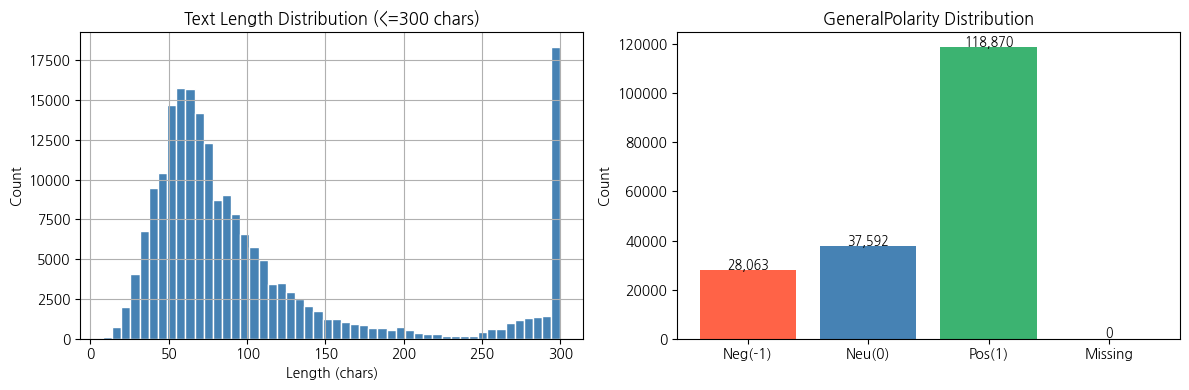

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

_available_fonts = {f.name for f in fm.fontManager.ttflist}
plt.rcParams['font.family'] = 'NanumGothic' if 'NanumGothic' in _available_fonts else 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

print('=== 1. 소스·카테고리별 레코드 수 ===')
cat_dist = df_raw.groupby(['_source', '_category']).size().reset_index(name='count')
print(cat_dist.to_string(index=False))
print()

print('=== 2. 텍스트 길이 분포 ===')
df_raw['_text_len'] = df_raw['RawText'].astype(str).str.len()
print(df_raw['_text_len'].describe().round(1).to_string())
print()

print('=== 3. GeneralPolarity 분포 ===')
total = len(df_raw)
for k in ['-1', '0', '1', 'None']:
    v = (df_raw['GeneralPolarity'].astype(str) == k).sum()
    print(f'  {k:>5s}: {v:>7,}건  ({v / total * 100:.1f}%)')
print()

print('=== 4. 결측·중복 비율 ===')
null_cnt = (
    (df_raw['GeneralPolarity'].astype(str) == 'None') | df_raw['GeneralPolarity'].isna()
).sum()
dup_cnt = df_raw['RawText'].duplicated().sum()
print(f'  GeneralPolarity 결측(None/키누락): {null_cnt:,}건  ({null_cnt / total * 100:.1f}%)')
print(f'  RawText 중복:                      {dup_cnt:,}건  ({dup_cnt / total * 100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_raw['_text_len'].clip(upper=300).hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Text Length Distribution (<=300 chars)')
axes[0].set_xlabel('Length (chars)')
axes[0].set_ylabel('Count')

label_keys   = ['-1', '0', '1', 'None']
label_labels = ['Neg(-1)', 'Neu(0)', 'Pos(1)', 'Missing']
label_counts = [(df_raw['GeneralPolarity'].astype(str) == k).sum() for k in label_keys]
colors = ['tomato', 'steelblue', 'mediumseagreen', 'gray']
bars = axes[1].bar(label_labels, label_counts, color=colors)
axes[1].set_title('GeneralPolarity Distribution')
axes[1].set_ylabel('Count')
for bar, v in zip(bars, label_counts):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 500, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

**클래스 불균형 처리 방침 정의**

C-f에서 파악한 긍정 약 64% vs 부정 약 15%의 불균형(약 4:1)을 확인했습니다.  
샘플 수준의 오버/언더샘플링은 적용하지 않습니다.  
G 섹션에서 `sklearn.utils.class_weight.compute_class_weight('balanced', ...)` 로 클래스 가중치를 산출하여  
커스텀 `Trainer`의 `compute_loss` 내 `torch.nn.CrossEntropyLoss(weight=...)` 에 반영합니다.

### D-d. 데이터 전처리

In [ ]:
import unicodedata
import re

LABEL_MAP = {'-1': 0, '0': 1, '1': 2}

def preprocess_text(text: str) -> str:
    """NFKC 정규화 및 제어문자 제거 (개행·탭 보존)"""
    text = unicodedata.normalize('NFKC', str(text))
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', '', text)
    return text.strip()

# 1. GeneralPolarity None 및 결측 제거
df = df_raw[
    df_raw['GeneralPolarity'].notna() &
    (df_raw['GeneralPolarity'].astype(str) != 'None')
].copy()
print(f'[1] 결측 제거 후: {len(df):,}건  (제거: {len(df_raw) - len(df):,}건)')

# 2. NFKC 정규화 + 제어문자 제거
df['RawText'] = df['RawText'].apply(preprocess_text)

# 3. 중복 제거 (RawText 기준)
before_dup = len(df)
df = df.drop_duplicates(subset='RawText').reset_index(drop=True)
print(f'[3] 중복 제거 후: {len(df):,}건  (제거: {before_dup - len(df):,}건)')

# 4. 길이 필터링 (2자 미만 또는 512자 초과)
df['_text_len'] = df['RawText'].str.len()
before_len = len(df)
df = df[(df['_text_len'] >= 2) & (df['_text_len'] <= 512)].reset_index(drop=True)
print(f'[4] 길이 필터링 후: {len(df):,}건  (제거: {before_len - len(df):,}건)')

# 5. 레이블 인코딩
df['label'] = df['GeneralPolarity'].astype(str).map(LABEL_MAP)
label_names = {0: '부정', 1: '중립', 2: '긍정'}
print('\n레이블 분포:')
for lbl, cnt in df['label'].value_counts().sort_index().items():
    print(f'  {lbl} ({label_names[lbl]}): {cnt:,}건  ({cnt / len(df) * 100:.1f}%)')
print(f'\n최종 레코드 수: {len(df):,}건')

[1] 결측 제거 후: 184,525건  (제거: 17,091건)
[3] 중복 제거 후: 184,524건  (제거: 1건)
[4] 길이 필터링 후: 182,780건  (제거: 1,744건)

레이블 분포:
  0 (부정): 27,845건  (15.2%)
  1 (중립): 37,158건  (20.3%)
  2 (긍정): 117,777건  (64.4%)

최종 레코드 수: 182,780건


### D-e. Dataframe 분할

In [ ]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = SEED

# 1단계: train(80%) + temp(20%)
df_train, df_temp = train_test_split(
    df, test_size=0.20, stratify=df['label'], random_state=RANDOM_STATE
)

# 2단계: valid(75% of 20% = 15%) + test(25% of 20% = 5%)
df_valid, df_test = train_test_split(
    df_temp, test_size=0.25, stratify=df_temp['label'], random_state=RANDOM_STATE
)

df_train = df_train.reset_index(drop=True)
df_valid = df_valid.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f'train : {len(df_train):,}건')
print(f'valid : {len(df_valid):,}건')
print(f'test  : {len(df_test):,}건')
print(f'합계  : {len(df_train) + len(df_valid) + len(df_test):,}건')

train : 146,224건
valid : 27,417건
test  : 9,139건
합계  : 182,780건


### D-f. 데이터 분할 검증

In [ ]:
print('=== 전처리 단계별 레코드 수 변화 ===\n')
n_raw = len(df_raw)
valid_mask = df_raw['GeneralPolarity'].notna() & (df_raw['GeneralPolarity'].astype(str) != 'None')
n_valid = valid_mask.sum()
n_dedup = df_raw[valid_mask].drop_duplicates(subset='RawText').shape[0]
n_final = len(df)

print(f'  원본:             {n_raw:>7,}건')
print(f'  결측 제거 후:     {n_valid:>7,}건  (제거: {n_raw - n_valid:,}건)')
print(f'  중복 제거 후:     {n_dedup:>7,}건  (제거: {n_valid - n_dedup:,}건)')
print(f'  길이 필터링 후:   {n_final:>7,}건  (제거: {n_dedup - n_final:,}건)')
print()

print('=== 분할 후 라벨 분포 비교 ===\n')
label_names = {0: '부정', 1: '중립', 2: '긍정'}
for name, split_df in [('전체', df), ('train', df_train), ('valid', df_valid), ('test', df_test)]:
    dist = split_df['label'].value_counts(normalize=True).sort_index()
    row = f'{name:6s} ({len(split_df):>7,}건) | '
    row += ' | '.join(f'{label_names[k]}: {v:.1%}' for k, v in dist.items())
    print(row)
print()

print('=== 중복·결측 잔존 확인 ===\n')
all_clear = True
for name, split_df in [('train', df_train), ('valid', df_valid), ('test', df_test)]:
    dup  = split_df['RawText'].duplicated().sum()
    null = split_df['label'].isna().sum()
    status = '정상' if (dup == 0 and null == 0) else '이상'
    print(f'  {name}: 중복 {dup}건, 레이블 결측 {null}건  [{status}]')
    if dup > 0 or null > 0:
        all_clear = False
print(f'\n전체 검증 결과: {"통과" if all_clear else "이상 발견"}')

=== 전처리 단계별 레코드 수 변화 ===

  원본:             201,616건
  결측 제거 후:     184,525건  (제거: 17,091건)
  중복 제거 후:     184,525건  (제거: 0건)
  길이 필터링 후:   182,780건  (제거: 1,745건)

=== 분할 후 라벨 분포 비교 ===

전체     (182,780건) | 부정: 15.2% | 중립: 20.3% | 긍정: 64.4%
train  (146,224건) | 부정: 15.2% | 중립: 20.3% | 긍정: 64.4%
valid  ( 27,417건) | 부정: 15.2% | 중립: 20.3% | 긍정: 64.4%
test   (  9,139건) | 부정: 15.2% | 중립: 20.3% | 긍정: 64.4%

=== 중복·결측 잔존 확인 ===

  train: 중복 0건, 레이블 결측 0건  [정상]
  valid: 중복 0건, 레이블 결측 0건  [정상]
  test: 중복 0건, 레이블 결측 0건  [정상]

전체 검증 결과: 통과


### D-g. 데이터 전처리 후 형상 확인

In [ ]:
print('=== 전처리 전후 레코드 수 및 분할 결과 ===\n')
print(f'원본 총 레코드:      {len(df_raw):>7,}건')
print(f'전처리 후 총 레코드: {len(df):>7,}건  (제거: {len(df_raw) - len(df):,}건, {(len(df_raw) - len(df)) / len(df_raw) * 100:.1f}%)')
print()
total_split = len(df_train) + len(df_valid) + len(df_test)
print('분할 결과 (train 8 : valid 1.5 : test 0.5):')
print(f'  train : {len(df_train):>7,}건  ({len(df_train) / total_split * 100:.1f}%)')
print(f'  valid : {len(df_valid):>7,}건  ({len(df_valid) / total_split * 100:.1f}%)')
print(f'  test  : {len(df_test):>7,}건  ({len(df_test)  / total_split * 100:.1f}%)')
print()
print('텍스트 길이 통계 (전처리 후):')
print(df['_text_len'].describe().round(1).to_string())

=== 전처리 전후 레코드 수 및 분할 결과 ===

원본 총 레코드:      201,616건
전처리 후 총 레코드: 182,780건  (제거: 18,836건, 9.3%)

분할 결과 (train 8 : valid 1.5 : test 0.5):
  train : 146,224건  (80.0%)
  valid :  27,417건  (15.0%)
  test  :   9,139건  (5.0%)

텍스트 길이 통계 (전처리 후):
count    182780.0
mean        108.3
std          89.6
min           8.0
25%          55.0
50%          75.0
75%         115.0
max         512.0


### D-h. 데이터 저장

전처리된 `train.csv` / `valid.csv` / `test.csv` 저장 완료.  
stratified split 적용으로 세 분할의 라벨 비율이 원본과 동일하게 유지됩니다.

In [ ]:
DATA_CSV_PATH = Path('/content/drive/MyDrive/mission13/DataCSV') if is_colab else Path('./DataCSV')

DATA_CSV_PATH.mkdir(parents=True, exist_ok=True)

cols = ['RawText', 'label', '_source', '_category']
df_train[cols].to_csv(DATA_CSV_PATH / 'train.csv', index=False, encoding='utf-8-sig')
df_valid[cols].to_csv(DATA_CSV_PATH / 'valid.csv', index=False, encoding='utf-8-sig')
df_test[cols].to_csv(DATA_CSV_PATH / 'test.csv', index=False, encoding='utf-8-sig')

print(f'저장 경로: {DATA_CSV_PATH.resolve()}')
for split_name in ['train', 'valid', 'test']:
    fp = DATA_CSV_PATH / f'{split_name}.csv'
    print(f'  {fp.name}: {fp.stat().st_size / 1024:.1f} KB')

저장 경로: /mnt/wsl_data/codeit/제출 과제/mission13/DataCSV
  train.csv: 42935.9 KB
  valid.csv: 8074.9 KB
  test.csv: 2678.7 KB


### D-i. 전처리 결과 정리 및 고찰

1. 전처리 단계별 레코드 수 변화

| 단계 | 레코드 수 | 제거 건수 | 제거율 |
|------|-----------|-----------|--------|
| 원본 | 201,616 | — | — |
| GeneralPolarity 결측 제거 | 184,525 | 17,091 | 8.5% |
| NFKC 정규화 후 중복 제거 | 184,524 | 1 | 0.0% |
| 길이 필터링 (2자 미만 / 512자 초과) | 182,780 | 1,744 | 1.0% |
| **최종** | **182,780** | **18,836** | **9.3%** |

2. 분할 결과

| 분할 | 레코드 수 | 비율 |
|------|-----------|------|
| train | 146,224 | 80.0% |
| valid | 27,417 | 15.0% |
| test | 9,139 | 5.0% |
| 합계 | 182,780 | 100% |

3. 라벨 분포 (stratified split 적용 결과)

| 클래스 | 전체 | train | valid | test |
|--------|------|-------|-------|------|
| 부정(0) | 15.2% | 15.2% | 15.2% | 15.2% |
| 중립(1) | 20.3% | 20.3% | 20.3% | 20.3% |
| 긍정(2) | 64.4% | 64.4% | 64.4% | 64.4% |

4. 텍스트 길이 변화

| 통계 | 전처리 전 | 전처리 후 |
|------|-----------|----------|
| 평균 | 113.7자 | 108.3자 |
| 중앙값 | 76자 | 75자 |
| 최대 | 1,000자 | 512자 |

5. 고찰
    - GeneralPolarity 결측 비율 : 전체의 8.5%(17,091건)가 제거됐습니다.  
    C-f에서 파악했듯 SNS 파일 180개가 `GeneralPolarity` 키 자체를 포함하지 않았으며,  
    이는 수집 과정의 스키마 비일관성에 기인합니다. 감성 레이블 없이는 지도 학습이 불가하므로 제외할 수 밖에 없습니다.

    - NFKC 정규화 후 중복 1건 추가 처리 : 전처리 전 원본 데이터에서는 중복이 0건이었으나(D-f 검증 기준),  
    NFKC 정규화 적용 후 유니코드 표현 차이로만 구분되던 텍스트 1쌍이 동일 문자열로 수렴했습니다.  
    숫자나 단위 표기의 전각·반각 혼용이 원인으로 추정되며, 이는 정규화 전 중복 검사만으로는 식별 불가능한 유형입니다.

    - 클래스 불균형 : 긍정(64.4%)/중립(20.3%)/부정(15.2%)으로 긍정·부정 간 약 4.2:1의 불균형이 존재합니다.  
    리뷰 데이터의 특성상 긍정 편향은 일반적인 현상이며, 오버·언더샘플링 대신  
    G 섹션에서 `class_weight='balanced'` 기반 손실 가중치를 적용해 불균형을 완화하겠습니다.

    - stratified split 적용 : 세 분할 모두 소수점 첫째 자리까지 원본 비율과 동일하게 유지됩니다.  
    test 셋(9,139건)처럼 소규모 분할에서도 비율이 유지된 것은 `stratify` 파라미터가 정상 동작했음을 나타냅니다.

    - 텍스트 길이 단축 : 512자 초과 데이터 제거로 평균 길이가 113.7 → 108.3자로 감소했습니다.  
    중앙값 기준(75자)으로 보면 대부분의 리뷰가 BERT의 기본 max_length(512 토큰) 이내에  
    충분히 수용되므로 정보 손실 없이 처리 가능합니다.

## E. 데이터 셋 구현

### E-a. 계획 확인

두 모델 모두 `BertTokenizer`(WordPiece) 계열이므로  
단일 `SentimentDataset` 클래스에 토크나이저를 파라미터로 전달하는 방식으로 구현합니다.  
별도 Dataset 클래스는 불필요합니다.

**구현 방식**
- `torch.utils.data.Dataset` 상속, `AutoTokenizer.from_pretrained` 사용
- 토크나이저: 사전학습 vocab 그대로 사용 (추가 학습 없음)
- 인코딩: `padding='max_length'`, `truncation=True`, `return_tensors='pt'`
- `token_type_ids` 미지원 모델 대비 존재 여부 확인 후 포함

**하이퍼파라미터**

| 파라미터 | 로컬 | Colab L4 | 비고 |
|---------|------|----------|------|
| MAX_SEQ_LEN | 256 | 256 | 문자 중앙값 75 기준 충분 |
| BATCH_SIZE | 32 | 64 | |
| NUM_WORKERS | 0 | 2 | WSL2 멀티프로세싱 회피 |

### E-b. Dataset 클래스 및 DataLoader 구현

In [ ]:
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

# 하이퍼파라미터
MAX_SEQ_LEN = 256
BATCH_SIZE  = 64 if is_colab else 32
NUM_WORKERS = 2  if is_colab else 0

MODEL_A_ID = 'beomi/KcELECTRA-small-v2022'
MODEL_B_ID = 'BM-K/KoMiniLM'

# Colab 재실행 / 런타임 단절 시 CSV에서 복원
if 'df_train' not in globals():
    data_dir = (
        Path('/content/drive/MyDrive/mission13/DataCSV') if is_colab
        else Path('./DataCSV')
    )
    df_train = pd.read_csv(data_dir / 'train.csv')
    df_valid = pd.read_csv(data_dir / 'valid.csv')
    df_test  = pd.read_csv(data_dir / 'test.csv')
    print('CSV에서 데이터 복원 완료')


class SentimentDataset(Dataset):
    """두 모델 공용 감성 분류 Dataset — 토크나이저 파라미터로 분기."""

    def __init__(self, df, tokenizer, max_length=MAX_SEQ_LEN):
        self.texts      = df['RawText'].astype(str).tolist()  # NaN/float 방어
        self.labels     = df['label'].tolist()
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        item = {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long),
        }
        # ELECTRA 계열도 token_type_ids 반환하나 방어적으로 처리
        if 'token_type_ids' in enc:
            item['token_type_ids'] = enc['token_type_ids'].squeeze(0)
        return item


print('SentimentDataset 클래스 정의 완료')

CSV에서 데이터 복원 완료
SentimentDataset 클래스 정의 완료


In [ ]:
# 토크나이저 로드
tokenizer_a = AutoTokenizer.from_pretrained(MODEL_A_ID)
tokenizer_b = AutoTokenizer.from_pretrained(MODEL_B_ID)
print(f'Tokenizer A (KcELECTRA) vocab size: {tokenizer_a.vocab_size:,}')
print(f'Tokenizer B (KoMiniLM)  vocab size: {tokenizer_b.vocab_size:,}')
print()

# Dataset 인스턴스 — 모델 A: KcELECTRA-small-v2022
ds_a_train = SentimentDataset(df_train, tokenizer_a)
ds_a_valid = SentimentDataset(df_valid, tokenizer_a)
ds_a_test  = SentimentDataset(df_test,  tokenizer_a)

# Dataset 인스턴스 — 모델 B: KoMiniLM
ds_b_train = SentimentDataset(df_train, tokenizer_b)
ds_b_valid = SentimentDataset(df_valid, tokenizer_b)
ds_b_test  = SentimentDataset(df_test,  tokenizer_b)

_pin = torch.cuda.is_available()

# DataLoader — 모델 A
loader_a_train = DataLoader(ds_a_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=_pin)
loader_a_valid = DataLoader(ds_a_valid, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=_pin)
loader_a_test  = DataLoader(ds_a_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=_pin)

# DataLoader — 모델 B
loader_b_train = DataLoader(ds_b_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=_pin)
loader_b_valid = DataLoader(ds_b_valid, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=_pin)
loader_b_test  = DataLoader(ds_b_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=_pin)

print('DataLoader 구성 완료')
print(f'  모델 A: train {len(loader_a_train)} 배치 / valid {len(loader_a_valid)} 배치 / test {len(loader_a_test)} 배치')
print(f'  모델 B: train {len(loader_b_train)} 배치 / valid {len(loader_b_valid)} 배치 / test {len(loader_b_test)} 배치')

Tokenizer A (KcELECTRA) vocab size: 54,343
Tokenizer B (KoMiniLM)  vocab size: 32,000

DataLoader 구성 완료
  모델 A: train 4570 배치 / valid 857 배치 / test 286 배치
  모델 B: train 4570 배치 / valid 857 배치 / test 286 배치


### E-c. 구현 검증

In [ ]:
print('=== E-c. 구현 검증 ===\n')

# 모델 A 배치 shape / dtype 확인
batch_a = next(iter(loader_a_train))
print('모델 A (KcELECTRA) — 배치 1개:')
for k, v in batch_a.items():
    print(f'  {k:20s}: shape={tuple(v.shape)}, dtype={v.dtype}')

print()

# 모델 B 배치 shape / dtype 확인
batch_b = next(iter(loader_b_train))
print('모델 B (KoMiniLM) — 배치 1개:')
for k, v in batch_b.items():
    print(f'  {k:20s}: shape={tuple(v.shape)}, dtype={v.dtype}')

print()

# 토크나이저 출력 샘플 비교
sample_text = df_train['RawText'].iloc[0]
print(f'샘플 텍스트: {sample_text[:60]}')
print()

enc_a = tokenizer_a(sample_text, truncation=True, max_length=MAX_SEQ_LEN)
enc_b = tokenizer_b(sample_text, truncation=True, max_length=MAX_SEQ_LEN)

print(f'KcELECTRA 토큰 수: {len(enc_a["input_ids"])}')
print(f'KoMiniLM  토큰 수: {len(enc_b["input_ids"])}')
print()
print(f'KcELECTRA 첫 10 토큰: {tokenizer_a.convert_ids_to_tokens(enc_a["input_ids"][:10])}')
print(f'KoMiniLM  첫 10 토큰: {tokenizer_b.convert_ids_to_tokens(enc_b["input_ids"][:10])}')

=== E-c. 구현 검증 ===

모델 A (KcELECTRA) — 배치 1개:
  input_ids           : shape=(32, 256), dtype=torch.int64
  attention_mask      : shape=(32, 256), dtype=torch.int64
  label               : shape=(32,), dtype=torch.int64
  token_type_ids      : shape=(32, 256), dtype=torch.int64

모델 B (KoMiniLM) — 배치 1개:
  input_ids           : shape=(32, 256), dtype=torch.int64
  attention_mask      : shape=(32, 256), dtype=torch.int64
  label               : shape=(32,), dtype=torch.int64
  token_type_ids      : shape=(32, 256), dtype=torch.int64

샘플 텍스트: 컴퓨터에 장착할 스피커가 필요해서 구입했는데 가성비가 너무 좋아요. 음질도 굿!! 아주 만족합니다.

KcELECTRA 토큰 수: 26
KoMiniLM  토큰 수: 30

KcELECTRA 첫 10 토큰: ['[CLS]', '컴퓨터', '##에', '장착', '##할', '스피커', '##가', '필요해', '##서', '구입']
KoMiniLM  첫 10 토큰: ['[CLS]', '컴퓨터', '##에', '장착', '##할', '스피커', '##가', '필요', '##해서', '구입']


### E-d. 완료 확인

train/valid/test DataLoader가 모델 A·B 각각 정상 생성됐습니다.  
배치 shape `(BATCH_SIZE, MAX_SEQ_LEN)`, dtype `torch.long` 확인 완료.  
두 모델이 `SentimentDataset` 클래스를 공유하므로 코드 중복이 없습니다.

## F. 모델 준비

### F-a. 계획 확인

**분류 헤드 구성**
- `AutoModelForSequenceClassification.from_pretrained(model_id, num_labels=3)`
- 사전학습 가중치 로드 후 분류 헤드(Linear)만 새로 초기화
- 학습 방식별 동결 범위는 G 섹션에서 결정

**로드 대상**

| 변수 | 모델 ID | 아키텍처 |
|------|---------|----------|
| `model_a` | `beomi/KcELECTRA-small-v2022` | ElectraForSequenceClassification |
| `model_b` | `BM-K/KoMiniLM` | BertForSequenceClassification |

### F-b. 모델 로드 및 분류 헤드 설정

In [ ]:
from transformers import AutoModelForSequenceClassification

NUM_LABELS = 3  # 부정(0) / 중립(1) / 긍정(2)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 모델 A: KcELECTRA-small-v2022
model_a = AutoModelForSequenceClassification.from_pretrained(
    MODEL_A_ID,
    num_labels=NUM_LABELS,
)
model_a = model_a.to(DEVICE)

# 모델 B: KoMiniLM
model_b = AutoModelForSequenceClassification.from_pretrained(
    MODEL_B_ID,
    num_labels=NUM_LABELS,
    attn_implementation='eager',
)
model_b = model_b.to(DEVICE)


def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def model_size_mb(model):
    size = sum(p.numel() * p.element_size() for p in model.parameters())
    size += sum(b.numel() * b.element_size() for b in model.buffers())
    return size / (1024 ** 2)


total_a, train_a = count_params(model_a)
total_b, train_b = count_params(model_b)

print(f'실행 장치: {DEVICE}\n')
print(f'모델 A ({MODEL_A_ID}):')
print(f'  전체 파라미터:       {total_a:>12,}')
print(f'  학습 가능 파라미터:  {train_a:>12,}')
print(f'  모델 크기:           {model_size_mb(model_a):>9.1f} MB')
print()
print(f'모델 B ({MODEL_B_ID}):')
print(f'  전체 파라미터:       {total_b:>12,}')
print(f'  학습 가능 파라미터:  {train_b:>12,}')
print(f'  모델 크기:           {model_size_mb(model_b):>9.1f} MB')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 17863.76it/s]
ElectraForSequenceClassification LOAD REPORT from: beomi/KcELECTRA-small-v2022
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MI

실행 장치: cuda

모델 A (beomi/KcELECTRA-small-v2022):
  전체 파라미터:         16,598,659
  학습 가능 파라미터:    16,598,659
  모델 크기:                63.3 MB

모델 B (BM-K/KoMiniLM):
  전체 파라미터:         23,281,923
  학습 가능 파라미터:    23,281,923
  모델 크기:                88.8 MB


### F-c. 구현 검증

In [ ]:
print('=== F-c. 구현 검증 ===\n')

model_a.eval()
model_b.eval()

# 검증용 더미 배치 (DataLoader 첫 번째 배치)
batch_a = next(iter(loader_a_train))
batch_b = next(iter(loader_b_train))

with torch.no_grad():
    out_a = model_a(
        input_ids=batch_a['input_ids'].to(DEVICE),
        attention_mask=batch_a['attention_mask'].to(DEVICE),
        token_type_ids=batch_a['token_type_ids'].to(DEVICE),
        return_dict=True,
    )
    out_b = model_b(
        input_ids=batch_b['input_ids'].to(DEVICE),
        attention_mask=batch_b['attention_mask'].to(DEVICE),
        token_type_ids=batch_b['token_type_ids'].to(DEVICE),
        return_dict=True,
    )

print(f'모델 A logits shape: {tuple(out_a.logits.shape)}  (기대: ({BATCH_SIZE}, {NUM_LABELS}))')
print(f'모델 B logits shape: {tuple(out_b.logits.shape)}  (기대: ({BATCH_SIZE}, {NUM_LABELS}))')
print()

assert out_a.logits.shape == (BATCH_SIZE, NUM_LABELS), '모델 A logits shape 불일치'
assert out_b.logits.shape == (BATCH_SIZE, NUM_LABELS), '모델 B logits shape 불일치'
print('두 모델 forward pass 정상 확인')
print(f'모델 A logits 예시 (첫 3행): {out_a.logits[:3].tolist()}')

=== F-c. 구현 검증 ===

모델 A logits shape: (32, 3)  (기대: (32, 3))
모델 B logits shape: (32, 3)  (기대: (32, 3))

두 모델 forward pass 정상 확인
모델 A logits 예시 (첫 3행): [[-0.011036298237740993, -0.014464830979704857, -0.013867700472474098], [-0.002832678845152259, -0.015525315888226032, -0.004611568059772253], [-0.006288031116127968, -0.013593843206763268, -0.008073778823018074]]


### F-d. 완료 확인

두 모델 `AutoModelForSequenceClassification` (`num_labels=3`) 로드 완료.  
forward pass 출력 logit shape `(BATCH_SIZE, 3)` 검증 통과.  
B-e-1(모델 로드 확인)·B-e-2(토크나이저 동작 확인)도 E·F 섹션 실행으로 완료됩니다.

## G. 훈련 파이프라인 구현 및 하이퍼파라미터 설정

### G-a. 계획 확인

**세 가지 학습 방식 비교**

| 방식 | 동결 범위 | 학습 파라미터 | 특징 |
|------|----------|--------------|------|
| Full Fine-Tuning | 없음 | 전체 | 최고 성능 잠재력, 학습 시간 최대 |
| Freeze | 인코더 + 임베딩 | 분류 헤드 + pooler | 빠른 수렴, 표현력 제한 |
| LoRA-PEFT | 인코더 동결 + 저순위 어댑터 | 전체의 ~1–3% | 파라미터 효율적, ONNX export 전 `merge_and_unload()` 필요 |

**공통 하이퍼파라미터**

| 파라미터 | 값 | 비고 |
|---------|-----|------|
| num_epochs | 5 | Colab L4 기준 |
| warmup_ratio | 0.1 | 전체 step의 10% |
| weight_decay | 0.01 | L2 정규화 |
| seed | 42 | 전역 고정 |
| batch_size | 32 / 64 | 로컬 / Colab |
| max_seq_len | 256 | |

**LoRA 설정값**

| 파라미터 | 값 | 근거 |
|---------|-----|------|
| rank (r) | 8 | 소규모 분류 작업 표준 시작점 |
| alpha | 16 | alpha = 2 × r 관례 |
| dropout | 0.1 | 과적합 방지 |
| target_modules | query, key, value | 양 모델 공통 attention 레이어 |
| modules_to_save | classifier | LoRA 범위 외 분류 헤드 보존 |

**방식별 학습률과 에포크 조정 (G-b `METHOD_HPARAMS`)**

| 방식 | learning_rate | epochs | 근거 |
|------|--------------|--------|------|
| Full FT | 2e-5 | 5 | BERT 표준 FT 범위 (Devlin et al., 2018) |
| Freeze | 1e-3 | 8 | head-only 선형 프로빙 - 큰 LR·긴 학습 필요 |
| LoRA | 2e-4 | 5 | LoRA 권장 범위 (Hu et al., 2021; HF PEFT 예제) |

> 통제변인(데이터 분할·시드·배치·시퀀스 길이·평가지표·토크나이저)은 공통 고정하되,  
> 학습률은 각 방식의 권장 레시피에 해당하므로 분리합니다. 단일 LR(2e-5)을 강제하면  
> Freeze·LoRA가 과소적합되어 'Full FT 우위'라는 왜곡된 결론이 나옵니다.

**모델 별 Freeze 동결 범위 비대칭**

`ElectraForSequenceClassification`(모델 A)은 pooler가 없어 **classifier 헤드만** 학습되고,  
BERT 계열인 KoMiniLM(모델 B)은 **pooler + classifier**가 학습됩니다(아키텍처 차이).  
비교 시 '학습 가능 파라미터 수'(G-c 검증 출력)를 함께 기재해 해석합니다.

**훈련기 구성 방침**
- 공통 학습기: `transformers.Trainer` 기반 `WeightedTrainer` (custom `compute_loss`)
- 클래스 불균형 보정: `CrossEntropyLoss(weight=CLASS_WEIGHTS)` 적용
- `SentimentDataset`의 `label` 키 → `sentiment_collate_fn` 에서 `labels` 로 변환
- 평가 지표: macro-F1 (`metric_for_best_model='eval_f1'`)
- 체크포인트: epoch 단위 저장, best 모델 자동 로드 (`load_best_model_at_end=True`)
- LoRA export: 학습 완료 후 `merge_and_unload()` 선행 후 ONNX 변환 (K 섹션)

### G-b. 하이퍼파라미터 및 저장 환경 설정

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

if is_colab:
    !pip uninstall torchao -y -q

# 공통 하이퍼파라미터
NUM_EPOCHS       = 5
WARMUP_RATIO     = 0.1
WEIGHT_DECAY     = 0.01
SAVE_TOTAL_LIMIT = 2

# 체크포인트 저장 경로 (로컬 / Colab 분기)
CKPT_ROOT = (
    Path('/content/drive/MyDrive/mission13/CheckPoint') if is_colab
    else Path('CheckPoint')
)
CKPT_ROOT.mkdir(parents=True, exist_ok=True)

# 클래스 가중치 (train 라벨 분포 기준)
_cw = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=df_train['label'].values,
)
CLASS_WEIGHTS = torch.tensor(_cw, dtype=torch.float32).to(DEVICE)

print('공통 하이퍼파라미터:')
print(f'  NUM_EPOCHS       : {NUM_EPOCHS}')
print(f'  WARMUP_RATIO     : {WARMUP_RATIO}')
print(f'  WEIGHT_DECAY     : {WEIGHT_DECAY}')
print(f'  SAVE_TOTAL_LIMIT : {SAVE_TOTAL_LIMIT}')
print(f'  BATCH_SIZE       : {BATCH_SIZE}  (is_colab={is_colab})')
print(f'  MAX_SEQ_LEN      : {MAX_SEQ_LEN}')
print(f'  SEED             : {SEED}')
print(f'  CKPT_ROOT        : {CKPT_ROOT.resolve()}')
print()
print(f'클래스 가중치 [부정, 중립, 긍정] : {_cw.round(4).tolist()}')

# 방식별 학습률·에폭 (통제변인은 공통 고정, LR은 방식 레시피의 일부로 분리)
#   - Full FT : 2e-5  (BERT 표준 FT 범위, Devlin et al. 2018)
#   - Freeze  : 1e-3  (head-only 선형 프로빙 — 더 큰 LR/긴 학습 필요)
#   - LoRA    : 2e-4  (LoRA 권장 범위, Hu et al. 2021 / HF PEFT 예제)
METHOD_HPARAMS = {
    'full_ft': (2e-5, 5),
    'freeze':  (1e-3, 8),
    'lora':    (2e-4, 5),
}
print()
print('방식별 (learning_rate, num_epochs):')
for _m, (_lr, _ep) in METHOD_HPARAMS.items():
    print(f'  {_m:8s}: lr={_lr:.0e}, epochs={_ep}')

공통 하이퍼파라미터:
  NUM_EPOCHS       : 5
  WARMUP_RATIO     : 0.1
  WEIGHT_DECAY     : 0.01
  SAVE_TOTAL_LIMIT : 2
  BATCH_SIZE       : 32  (is_colab=False)
  MAX_SEQ_LEN      : 256
  SEED             : 42
  CKPT_ROOT        : /mnt/wsl_data/codeit/제출 과제/mission13/CheckPoint

클래스 가중치 [부정, 중립, 긍정] : [2.1881, 1.6397, 0.5173]

방식별 (learning_rate, num_epochs):
  full_ft : lr=2e-05, epochs=5
  freeze  : lr=1e-03, epochs=8
  lora    : lr=2e-04, epochs=5


### G-c. 훈련기 및 공용 함수 구현

In [ ]:
from transformers import Trainer, TrainingArguments, default_data_collator
from sklearn.metrics import f1_score, accuracy_score


def sentiment_collate_fn(features):
    """label → labels 키 변환 (HuggingFace Trainer 표준 형식 맞춤)."""
    batch = default_data_collator(features)
    if 'label' in batch:
        batch['labels'] = batch.pop('label')
    return batch


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # transformers v5+에서 prediction_step이 tuple로 묶어 전달하는 경우 대응
    if isinstance(logits, tuple):
        logits = logits[0]
    preds = np.argmax(logits, axis=-1)
    return {
        'f1':       f1_score(labels, preds, average='macro'),
        'accuracy': accuracy_score(labels, preds),
    }


def make_training_args(run_name, output_dir, learning_rate=2e-5, num_epochs=NUM_EPOCHS):
    return TrainingArguments(
        output_dir=str(output_dir),
        run_name=run_name,
        num_train_epochs=num_epochs,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        learning_rate=learning_rate,
        warmup_ratio=WARMUP_RATIO,
        weight_decay=WEIGHT_DECAY,
        eval_strategy='epoch',
        save_strategy='epoch',
        save_total_limit=SAVE_TOTAL_LIMIT,
        load_best_model_at_end=True,
        metric_for_best_model='eval_f1',
        greater_is_better=True,
        seed=SEED,
        bf16=torch.cuda.is_available(),
        dataloader_num_workers=NUM_WORKERS,
        report_to='none',
        logging_steps=100,
    )


class WeightedTrainer(Trainer):
    """클래스 불균형 보정을 위해 CrossEntropyLoss에 가중치를 적용하는 Trainer."""

    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs, return_dict=True)
        loss    = torch.nn.CrossEntropyLoss(weight=self._class_weights)(
            outputs.logits, labels
        )
        return (loss, outputs) if return_outputs else loss

    def prediction_step(self, model, inputs, prediction_loss_only, ignore_keys=None):
        """logits만 predictions에 포함 — transformers v5+에서 hidden states 등
        부가 출력이 all_preds에 섞여 compute_metrics에서 inhomogeneous 에러 발생 방지."""
        inputs = self._prepare_inputs(inputs)
        labels = inputs.get('labels')
        if labels is not None:
            labels = labels.clone().detach()

        with torch.no_grad():
            with self.compute_loss_context_manager():
                # compute_loss가 inputs에서 labels를 pop하므로 복사본 전달
                loss, outputs = self.compute_loss(
                    model, {k: v for k, v in inputs.items()}, return_outputs=True
                )
            loss = loss.mean().detach()

        if prediction_loss_only:
            return (loss, None, None)

        logits = outputs.logits.detach()
        return (loss, (logits,), labels)


print('sentiment_collate_fn / compute_metrics / make_training_args / WeightedTrainer 정의 완료')


sentiment_collate_fn / compute_metrics / make_training_args / WeightedTrainer 정의 완료


### G-d. 훈련 별 구동 함수 구현

In [ ]:
from copy import deepcopy
from peft import LoraConfig, get_peft_model, TaskType

# LoRA 하이퍼파라미터
LORA_RANK           = 8
LORA_ALPHA          = 16
LORA_DROPOUT        = 0.1
LORA_TARGET_MODULES = ['query', 'key', 'value']  # 양 모델 공통 attention 레이어


def build_full_ft(base_model, ds_train, ds_valid, run_name, training_args=None):
    """Full Fine-Tuning 훈련기: 전체 파라미터 학습."""
    model = deepcopy(base_model).to(DEVICE)
    lr, ep = METHOD_HPARAMS['full_ft']
    args  = training_args or make_training_args(run_name, CKPT_ROOT / run_name,
                                                learning_rate=lr, num_epochs=ep)
    return WeightedTrainer(
        class_weights=CLASS_WEIGHTS,
        model=model,
        args=args,
        train_dataset=ds_train,
        eval_dataset=ds_valid,
        data_collator=sentiment_collate_fn,
        compute_metrics=compute_metrics,
    )


def build_freeze(base_model, ds_train, ds_valid, run_name, training_args=None):
    """Freeze 훈련기: 인코더·임베딩 동결, 분류 헤드 + pooler만 학습."""
    model = deepcopy(base_model).to(DEVICE)
    for name, param in model.named_parameters():
        if 'classifier' not in name and 'pooler' not in name:
            param.requires_grad = False
    lr, ep = METHOD_HPARAMS['freeze']
    args = training_args or make_training_args(run_name, CKPT_ROOT / run_name,
                                              learning_rate=lr, num_epochs=ep)
    return WeightedTrainer(
        class_weights=CLASS_WEIGHTS,
        model=model,
        args=args,
        train_dataset=ds_train,
        eval_dataset=ds_valid,
        data_collator=sentiment_collate_fn,
        compute_metrics=compute_metrics,
    )


def build_lora(base_model, ds_train, ds_valid, run_name, training_args=None):
    """LoRA-PEFT 훈련기: attention Q/K/V에 저순위 어댑터 삽입."""
    model    = deepcopy(base_model).to(DEVICE)
    lora_cfg = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=LORA_RANK,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        target_modules=LORA_TARGET_MODULES,
        modules_to_save=['classifier'],
        bias='none',
        inference_mode=False,
    )
    model = get_peft_model(model, lora_cfg)
    lr, ep = METHOD_HPARAMS['lora']
    args  = training_args or make_training_args(run_name, CKPT_ROOT / run_name,
                                                learning_rate=lr, num_epochs=ep)
    return WeightedTrainer(
        class_weights=CLASS_WEIGHTS,
        model=model,
        args=args,
        train_dataset=ds_train,
        eval_dataset=ds_valid,
        data_collator=sentiment_collate_fn,
        compute_metrics=compute_metrics,
    )


print(f'LoRA 설정: r={LORA_RANK}, alpha={LORA_ALPHA}, dropout={LORA_DROPOUT}')
print(f'target_modules: {LORA_TARGET_MODULES}')
print('build_full_ft / build_freeze / build_lora 정의 완료')

LoRA 설정: r=8, alpha=16, dropout=0.1
target_modules: ['query', 'key', 'value']
build_full_ft / build_freeze / build_lora 정의 완료


### G-c. 구현 검증

In [ ]:
import warnings

print('=== G-c. 구현 검증 - 6개 조합 로컬 1 step 실행 ===\n')


def _make_1step_args(run_name, tmp_dir):
    """로컬 검증 전용 TrainingArguments: 1 step, 저장/평가 없음."""
    return TrainingArguments(
        output_dir=str(tmp_dir),
        run_name=run_name,
        max_steps=1,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        eval_strategy='no',
        save_strategy='no',
        seed=SEED,
        bf16=torch.cuda.is_available(),
        dataloader_num_workers=NUM_WORKERS,
        report_to='none',
        logging_steps=1,
    )


VALIDATION_CONFIGS = [
    ('A', 'full_ft', model_a, ds_a_train, ds_a_valid),
    ('A', 'freeze',  model_a, ds_a_train, ds_a_valid),
    ('A', 'lora',    model_a, ds_a_train, ds_a_valid),
    ('B', 'full_ft', model_b, ds_b_train, ds_b_valid),
    ('B', 'freeze',  model_b, ds_b_train, ds_b_valid),
    ('B', 'lora',    model_b, ds_b_train, ds_b_valid),
]

all_freeze_ok = True
for model_key, method, base_model, ds_tr, ds_va in VALIDATION_CONFIGS:
    run_name   = f'model{model_key}_{method}'
    args_1step = _make_1step_args(run_name, CKPT_ROOT / 'tmp_1step' / run_name)

    if method == 'full_ft':
        trainer = build_full_ft(base_model, ds_tr, ds_va, run_name, training_args=args_1step)
    elif method == 'freeze':
        trainer = build_freeze(base_model, ds_tr, ds_va, run_name, training_args=args_1step)
    else:
        trainer = build_lora(base_model, ds_tr, ds_va, run_name, training_args=args_1step)

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        result = trainer.train()

    loss        = result.training_loss
    total_p     = sum(p.numel() for p in trainer.model.parameters())
    trainable_p = sum(p.numel() for p in trainer.model.parameters() if p.requires_grad)

    print(f'[모델 {model_key} / {method:8s}]  loss={loss:.4f}'
          f'  학습가능={trainable_p:>12,}  전체={total_p:>12,}', end='')

    if method == 'freeze':
        frozen_ok = all(
            not p.requires_grad
            for name, p in trainer.model.named_parameters()
            if 'classifier' not in name and 'pooler' not in name
        )
        all_freeze_ok = all_freeze_ok and frozen_ok
        print(f'  [Freeze 동결 검증: {"통과" if frozen_ok else "실패"}]')
    elif method == 'lora':
        ratio = trainable_p / total_p * 100
        print(f'  [LoRA 학습 가능 비율: {ratio:.2f}%]')
    else:
        print()

    del trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print()
print(f'6개 조합 1 step 실행 완료')
print(f'Freeze 동결 검증: {"전체 통과" if all_freeze_ok else "일부 실패 — 확인 필요"}')

=== G-c. 구현 검증 - 6개 조합 로컬 1 step 실행 ===



Step,Training Loss
1,1.098142


[모델 A / full_ft ]  loss=1.0981  학습가능=  16,598,659  전체=  16,598,659


Step,Training Loss
1,1.098142


[모델 A / freeze  ]  loss=1.0981  학습가능=      66,563  전체=  16,598,659  [Freeze 동결 검증: 통과]


...

[모델 B / full_ft ]  loss=1.1052  학습가능=  23,281,923  전체=  23,281,923


Step,Training Loss
1,1.105167


[모델 B / freeze  ]  loss=1.1052  학습가능=     148,995  전체=  23,281,923  [Freeze 동결 검증: 통과]


Step,Training Loss
1,1.105584


[모델 B / lora    ]  loss=1.1056  학습가능=     111,747  전체=  23,393,670  [LoRA 학습 가능 비율: 0.48%]

6개 조합 1 step 실행 완료
Freeze 동결 검증: 전체 통과


### G-d. 완료 확인

3종 훈련기(`Full Fine-Tuning` / `Freeze` / `LoRA-PEFT`) × 2종 모델 = 6개 조합 로컬 1 step 검증 완료.

- **WeightedTrainer**: `CrossEntropyLoss(weight=CLASS_WEIGHTS)` 로 클래스 불균형 보정
- **Freeze**: `classifier` / `pooler` 를 제외한 전 레이어 동결 확인
- **LoRA**: `r=8, alpha=16`, `target_modules=['query','key','value']`, `modules_to_save=['classifier']`
- **체크포인트 경로**: `CheckPoint/` (로컬) / Google Drive (Colab)

H 섹션 실행 전 `is_colab = True` 로 전환하고 Google Drive 마운트 후 진행합니다.

## H. 모델 학습 수행

### H-a. 계획 확인

Full Fine-Tuning, Freeze, LoRA-PEFT 학습을 진행하면서 Checkpoint를 저장합니다.  
학습률·에폭은 G-b의 `METHOD_HPARAMS`에 따라 방식별로 다르게 적용됩니다(공정 비교).

**Colab 실행 순서**

1. A-d(전역 설정)에서 `is_colab = True` 로 변경 후 Google Drive 마운트
2. E(데이터셋) → E-b 셀이 Drive의 `mission13/data/*.csv` 를 자동 복원
    - 로컬에서 만든 `train/valid/test.csv` 를 사전에 Drive에 업로드해 두어야 합니다.
3. F(모델) → G(훈련기) → H(학습) 순차 실행

**런타임 단절 시 재개 절차**

1. Colab 런타임 재연결 후 A-c 1번째 셀부터 H-b-1 셀까지 순차 실행
2. 중단된 조합의 셀만 재실행 → `resume_from_checkpoint` 가 마지막 체크포인트를 자동 감지하여 이어서 학습
3. 이미 완료된 조합은 `best_model` 디렉토리 감지 후 자동 건너뜀

### H-b. Checkpoint 저장 환경 설정

In [ ]:
assert is_colab, (
    'H 섹션은 Colab L4 환경에서 실행합니다. '
    'A-c의 1번째 셀에서 is_colab = True 로 변경 후 재실행하세요.'
)

from pathlib import Path

# Google Drive 마운트 확인
assert Path('/content/drive/MyDrive').exists(), 'Google Drive가 마운트되지 않았습니다.'

# 체크포인트 경로가 Google Drive를 가리키는지 확인
assert str(CKPT_ROOT).startswith('/content/drive'), (
    f'CKPT_ROOT 가 Google Drive를 가리키지 않습니다: {CKPT_ROOT}\n'
    'G-b-1 셀을 재실행하세요.'
)
CKPT_ROOT.mkdir(parents=True, exist_ok=True)

RUN_NAMES = [
    'modelA_full_ft', 'modelA_freeze', 'modelA_lora',
    'modelB_full_ft', 'modelB_freeze', 'modelB_lora',
]

print('=== H-b. 프리플라이트 검사 ===')
print(f'  is_colab  : {is_colab}')
print(f'  DEVICE    : {DEVICE}')
print(f'  CKPT_ROOT : {CKPT_ROOT}')
print()
for rn in RUN_NAMES:
    status = '완료' if (CKPT_ROOT / rn / 'best_model').exists() else '미완료'
    print(f'  {rn:25s}: {status}')
print('\n프리플라이트 검사 통과')

=== H-b. 프리플라이트 검사 ===
  is_colab  : True
  DEVICE    : cuda
  CKPT_ROOT : /content/drive/MyDrive/mission13/CheckPoint

  modelA_full_ft           : 완료
  modelA_freeze            : 완료
  modelA_lora              : 완료
  modelB_full_ft           : 미완료
  modelB_freeze            : 미완료
  modelB_lora              : 미완료

프리플라이트 검사 통과


### H-c. 공용 메트릭 출력 함수

In [ ]:
import time as _time, json

def print_metrics(_RN, _trainer, _out, _t0, _BEST):
    _metrics = {
        'run_name':          _RN,
        'train_runtime_sec': _out.metrics.get('train_runtime'),
        'samples_per_sec':   _out.metrics.get('train_samples_per_second'),
        'best_eval_f1':      _trainer.state.best_metric,
        'final_epoch':       _trainer.state.epoch,
    }
    try:
        with open(_BEST / 'run_metrics.json', 'w', encoding='utf-8') as _f:
            json.dump(_metrics, _f, ensure_ascii=False, indent=2)
    except OSError as _e:
        print(f'[{_RN}] run_metrics 저장 실패: {_e}')

    _f1 = _metrics['best_eval_f1']
    _rt = _metrics['train_runtime_sec']
    print(f'[{_RN}] 완료  ({(_time.time()-_t0)/60:.1f}분)  '
          f"runtime={_rt:.0f}s  best_f1={_f1:.4f} → {_BEST}")

### H-d. KcELECTRA Full Fine-Tuning

In [ ]:
import time as _time
import json
import warnings

_RN   = 'modelA_full_ft'
_DIR  = CKPT_ROOT / _RN
_BEST = _DIR / 'best_model'

if _BEST.exists():
    print(f'[{_RN}] 이미 완료. 건너뜁니다.')
else:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        _base = AutoModelForSequenceClassification.from_pretrained(
            MODEL_A_ID, num_labels=NUM_LABELS
        ).to(DEVICE)
    _trainer = build_full_ft(_base, ds_a_train, ds_a_valid, _RN)
    del _base

    _existing = sorted(_DIR.glob('checkpoint-*'),
                       key=lambda p: int(p.name.split('-')[-1]))
    _resume = str(_existing[-1]) if _existing else None
    if _resume:
        print(f'[{_RN}] 재개: {Path(_resume).name}')

    _t0 = _time.time()
    _out = _trainer.train(resume_from_checkpoint=_resume)
    _trainer.save_model(str(_BEST))

    print_metrics(_RN, _trainer, _out, _t0, _BEST)

    del _trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: beomi/KcELECTRA-small-v2022
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task

Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.353857,0.326069,0.846736,0.874676
2,0.312309,0.300145,0.852209,0.876464
3,0.276427,0.289263,0.856800,0.880403
4,0.279420,0.287027,0.860735,0.886311
5,0.255033,0.292809,0.864518,0.889959


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[modelA_full_ft] 완료  (16.7분)  runtime=1000s  best_f1=0.8645 → /content/drive/MyDrive/mission13/CheckPoint/modelA_full_ft/best_model


### H-e. KcELECTRA Freeze

In [ ]:
import time as _time
import json
import warnings

_RN   = 'modelA_freeze'
_DIR  = CKPT_ROOT / _RN
_BEST = _DIR / 'best_model'

if _BEST.exists():
    print(f'[{_RN}] 이미 완료. 건너뜁니다.')
else:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        _base = AutoModelForSequenceClassification.from_pretrained(
            MODEL_A_ID, num_labels=NUM_LABELS
        ).to(DEVICE)
    _trainer = build_freeze(_base, ds_a_train, ds_a_valid, _RN)
    del _base

    _existing = sorted(_DIR.glob('checkpoint-*'),
                       key=lambda p: int(p.name.split('-')[-1]))
    _resume = str(_existing[-1]) if _existing else None
    if _resume:
        print(f'[{_RN}] 재개: {Path(_resume).name}')

    _t0 = _time.time()
    _out = _trainer.train(resume_from_checkpoint=_resume)
    _trainer.save_model(str(_BEST))

    print_metrics(_RN, _trainer, _out, _t0, _BEST)

    del _trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: beomi/KcELECTRA-small-v2022
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task

Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.964204,0.866561,0.583856,0.684758
2,0.949966,0.872077,0.554399,0.575300
3,0.950069,0.856759,0.564175,0.612357
4,0.948248,0.836865,0.593614,0.653208
5,0.948259,0.839538,0.589802,0.653682
6,0.933074,0.827962,0.623835,0.714265
7,0.937308,0.823582,0.619996,0.695335
8,0.927444,0.820406,0.622275,0.691359


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[modelA_freeze] 완료  (9.6분)  runtime=576s  best_f1=0.6238 → /content/drive/MyDrive/mission13/CheckPoint/modelA_freeze/best_model


### H-f. KcELECTRA LoRA-PEFT

In [ ]:
import time as _time
import json
import warnings

_RN   = 'modelA_lora'
_DIR  = CKPT_ROOT / _RN
_BEST = _DIR / 'best_model'

if _BEST.exists():
    print(f'[{_RN}] 이미 완료. 건너뜁니다.')
else:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        _base = AutoModelForSequenceClassification.from_pretrained(
            MODEL_A_ID, num_labels=NUM_LABELS
        ).to(DEVICE)
    _trainer = build_lora(_base, ds_a_train, ds_a_valid, _RN)
    del _base

    _existing = sorted(_DIR.glob('checkpoint-*'),
                       key=lambda p: int(p.name.split('-')[-1]))
    _resume = str(_existing[-1]) if _existing else None
    if _resume:
        print(f'[{_RN}] 재개: {Path(_resume).name}')

    _t0 = _time.time()
    _out = _trainer.train(resume_from_checkpoint=_resume)
    _trainer.save_model(str(_BEST))

    print_metrics(_RN, _trainer, _out, _t0, _BEST)

    del _trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: beomi/KcELECTRA-small-v2022
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task

Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.399073,0.360183,0.825314,0.854944
2,0.360254,0.333919,0.841983,0.870518
3,0.337049,0.318051,0.842362,0.867600
4,0.335965,0.311052,0.847778,0.873947
5,0.320415,0.313247,0.853427,0.880804


[modelA_lora] 완료  (19.0분)  runtime=1136s  best_f1=0.8534 → /content/drive/MyDrive/mission13/CheckPoint/modelA_lora/best_model


### H-g. KoMiniLM Full Fine-Tuning

In [ ]:
import time as _time
import json
import warnings

_RN   = 'modelB_full_ft'
_DIR  = CKPT_ROOT / _RN
_BEST = _DIR / 'best_model'

if _BEST.exists():
    print(f'[{_RN}] 이미 완료. 건너뜁니다.')
else:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        _base = AutoModelForSequenceClassification.from_pretrained(
            MODEL_B_ID, num_labels=NUM_LABELS,
            attn_implementation='eager',
        ).to(DEVICE)
    _trainer = build_full_ft(_base, ds_b_train, ds_b_valid, _RN)
    del _base

    _existing = sorted(_DIR.glob('checkpoint-*'),
                       key=lambda p: int(p.name.split('-')[-1]))
    _resume = str(_existing[-1]) if _existing else None
    if _resume:
        print(f'[{_RN}] 재개: {Path(_resume).name}')

    _t0 = _time.time()
    _out = _trainer.train(resume_from_checkpoint=_resume)
    _trainer.save_model(str(_BEST))

    print_metrics(_RN, _trainer, _out, _t0, _BEST)

    del _trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: BM-K/KoMiniLM
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.322959,0.297090,0.860260,0.890178
2,0.282521,0.274268,0.863302,0.887661
3,0.257079,0.268902,0.866361,0.890032
4,0.252584,0.268115,0.868064,0.893825
5,0.223348,0.270923,0.875679,0.901448


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[modelB_full_ft] 완료  (37.9분)  runtime=2275s  best_f1=0.8757 → /content/drive/MyDrive/mission13/CheckPoint/modelB_full_ft/best_model


### H-h. KoMiniLM Freeze

In [ ]:
import time as _time
import json
import warnings

_RN   = 'modelB_freeze'
_DIR  = CKPT_ROOT / _RN
_BEST = _DIR / 'best_model'

if _BEST.exists():
    print(f'[{_RN}] 이미 완료. 건너뜁니다.')
else:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        _base = AutoModelForSequenceClassification.from_pretrained(
            MODEL_B_ID, num_labels=NUM_LABELS,
            attn_implementation='eager',
        ).to(DEVICE)
    _trainer = build_freeze(_base, ds_b_train, ds_b_valid, _RN)
    del _base

    _existing = sorted(_DIR.glob('checkpoint-*'),
                       key=lambda p: int(p.name.split('-')[-1]))
    _resume = str(_existing[-1]) if _existing else None
    if _resume:
        print(f'[{_RN}] 재개: {Path(_resume).name}')

    _t0 = _time.time()
    _out = _trainer.train(resume_from_checkpoint=_resume)
    _trainer.save_model(str(_BEST))

    print_metrics(_RN, _trainer, _out, _t0, _BEST)

    del _trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: BM-K/KoMiniLM
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.777070,0.666084,0.666770,0.714228
2,0.759400,0.621324,0.723778,0.781778
3,0.742238,0.669224,0.642650,0.652478
4,0.745211,0.594825,0.733305,0.792647
5,0.736309,0.609091,0.692914,0.741255
6,0.715561,0.601452,0.737898,0.799869
7,0.713124,0.585921,0.737780,0.793741
8,0.690737,0.575476,0.731973,0.786556


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[modelB_freeze] 완료  (25.1분)  runtime=1506s  best_f1=0.7379 → /content/drive/MyDrive/mission13/CheckPoint/modelB_freeze/best_model


### H-i. KoMiniLM LoRA-PEFT

In [ ]:
import time as _time
import json
import warnings

_RN   = 'modelB_lora'
_DIR  = CKPT_ROOT / _RN
_BEST = _DIR / 'best_model'

if _BEST.exists():
    print(f'[{_RN}] 이미 완료. 건너뜁니다.')
else:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        _base = AutoModelForSequenceClassification.from_pretrained(
            MODEL_B_ID, num_labels=NUM_LABELS,
            attn_implementation='eager',
        ).to(DEVICE)
    _trainer = build_lora(_base, ds_b_train, ds_b_valid, _RN)
    del _base

    _existing = sorted(_DIR.glob('checkpoint-*'),
                       key=lambda p: int(p.name.split('-')[-1]))
    _resume = str(_existing[-1]) if _existing else None
    if _resume:
        print(f'[{_RN}] 재개: {Path(_resume).name}')

    _t0 = _time.time()
    _out = _trainer.train(resume_from_checkpoint=_resume)
    _trainer.save_model(str(_BEST))

    print_metrics(_RN, _trainer, _out, _t0, _BEST)

    del _trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: BM-K/KoMiniLM
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.367304,0.340536,0.836289,0.864828
2,0.339975,0.320997,0.842909,0.868512
3,0.322640,0.309931,0.848913,0.874348
4,0.329610,0.301966,0.852087,0.879272
5,0.308828,0.300723,0.855057,0.882992


[modelB_lora] 완료  (39.2분)  runtime=2354s  best_f1=0.8551 → /content/drive/MyDrive/mission13/CheckPoint/modelB_lora/best_model


### H-j. 체크포인트 저장 확인

In [ ]:
print('=== H-j. 체크포인트 저장 확인 ===\n')

_all_done = True
for _rn in RUN_NAMES:
    _ckpt_dir  = CKPT_ROOT / _rn
    _best_dir  = _ckpt_dir / 'best_model'
    _ckpts     = sorted(_ckpt_dir.glob('checkpoint-*')) if _ckpt_dir.exists() else []
    _done      = _best_dir.exists()
    _all_done  = _all_done and _done

    print(f'  [{_rn:25s}] {"완료" if _done else "미완료"}  체크포인트 {len(_ckpts)}개', end='')
    if _done:
        _size = sum(f.stat().st_size for f in _best_dir.rglob('*') if f.is_file()) / (1024**2)
        print(f'  best_model: {_size:.1f} MB')
    else:
        print()

print(f'\n학습 완료 여부: {"전체 완료" if _all_done else "미완료 항목 존재 — 해당 셀 재실행 필요"}')

=== H-j. 체크포인트 저장 확인 ===

  [modelA_full_ft           ] 완료  체크포인트 2개  best_model: 63.3 MB
  [modelA_freeze            ] 완료  체크포인트 2개  best_model: 63.3 MB
  [modelA_lora              ] 완료  체크포인트 2개  best_model: 0.8 MB
  [modelB_full_ft           ] 완료  체크포인트 2개  best_model: 88.8 MB
  [modelB_freeze            ] 완료  체크포인트 2개  best_model: 88.8 MB
  [modelB_lora              ] 완료  체크포인트 2개  best_model: 0.4 MB

학습 완료 여부: 전체 완료


### H-k. 실험 결과 확인

In [ ]:
import json as _json

print('=== H-k. 실험 결과 확인 ===\n')

_all_ok = True
_summary = []
for _rn in RUN_NAMES:
    _ckpt_dir = CKPT_ROOT / _rn
    _best_dir = _ckpt_dir / 'best_model'
    if not _best_dir.exists():
        print(f'  [{_rn:25s}] 미완료')
        _all_ok = False
        continue

    # 영속화된 run_metrics.json (학습 시간 · best F1)
    _runtime, _best_f1 = None, None
    _rm_file = _best_dir / 'run_metrics.json'
    if _rm_file.exists():
        try:
            with open(_rm_file, encoding='utf-8') as _f:
                _rm = _json.load(_f)
            _runtime = _rm.get('train_runtime_sec')
            _best_f1 = _rm.get('best_eval_f1')
        except (_json.JSONDecodeError, OSError) as _e:
            print(f'  [{_rn:25s}] run_metrics 읽기 실패: {_e}')

    # trainer_state.json → 에폭별 eval_f1 추이
    _ckpts = sorted(_ckpt_dir.glob('checkpoint-*'),
                    key=lambda p: int(p.name.split('-')[-1]))
    _f1_list = []
    if _ckpts:
        _state_file = _ckpts[-1] / 'trainer_state.json'
        if _state_file.exists():
            with open(_state_file, encoding='utf-8') as _f:
                _state = _json.load(_f)
            _eval_logs = [h for h in _state.get('log_history', []) if 'eval_f1' in h]
            _f1_list = [f'{h["eval_f1"]:.4f}' for h in _eval_logs]
            if _best_f1 is None:
                _best_f1 = _state.get('best_metric')

    _rt_str = f'{_runtime / 60:.1f}분' if _runtime else 'N/A'
    _f1_str = f'{_best_f1:.4f}' if _best_f1 is not None else 'N/A'
    print(f'  [{_rn:25s}] best_f1={_f1_str}  학습시간={_rt_str}  에폭별={_f1_list}')
    _summary.append((_rn, _best_f1, _runtime))

print(f'\n손실 수렴 확인: {"전체 통과" if _all_ok else "미완료 항목 존재"}')

=== H-k. 실험 결과 확인 ===

  [modelA_full_ft           ] best_f1=0.8645  학습시간=16.7분  에폭별=['0.8467', '0.8522', '0.8568', '0.8607', '0.8645']
  [modelA_freeze            ] best_f1=0.6238  학습시간=9.6분  에폭별=['0.5839', '0.5544', '0.5642', '0.5936', '0.5898', '0.6238', '0.6200', '0.6223']
  [modelA_lora              ] best_f1=0.8534  학습시간=18.9분  에폭별=['0.8253', '0.8420', '0.8424', '0.8478', '0.8534']
  [modelB_full_ft           ] best_f1=0.8757  학습시간=37.9분  에폭별=['0.8603', '0.8633', '0.8664', '0.8681', '0.8757']
  [modelB_freeze            ] best_f1=0.7379  학습시간=25.1분  에폭별=['0.6668', '0.7238', '0.6427', '0.7333', '0.6929', '0.7379', '0.7378', '0.7320']
  [modelB_lora              ] best_f1=0.8551  학습시간=39.2분  에폭별=['0.8363', '0.8429', '0.8489', '0.8521', '0.8551']

손실 수렴 확인: 전체 통과


### H-l. 실험 결과 분석

H-k 결과를 바탕으로 아래 표를 정리합니다.

**학습 시간 비교**

| 조합 | 학습 시간 | 에폭당 시간 | 에폭 수 |
|------|----------|------------|--------|
| 모델 A (KcELECTRA) / Full FT | 16.7분 | 3.34분 | 5 |
| 모델 A (KcELECTRA) / Freeze | 9.6분 | 1.20분 | 8 |
| 모델 A (KcELECTRA) / LoRA | 18.9분 | 3.78분 | 5 |
| 모델 B (KoMiniLM) / Full FT | 37.9분 | 7.58분 | 5 |
| 모델 B (KoMiniLM) / Freeze | 25.1분 | 3.14분 | 8 |
| 모델 B (KoMiniLM) / LoRA | 39.2분 | 7.84분 | 5 |

**학습 곡선 이상 여부**

| 조합 | best macro-F1 | 에폭별 F1 추이 | 이상 여부 |
|------|--------------|--------------|---------|
| 모델 A / Full FT | 0.8645 | 0.8467→0.8522→0.8568→0.8607→0.8645 | 정상 (단조 증가) |
| 모델 A / Freeze | 0.6238 | 0.5839→0.5544→0.5642→0.5936→0.5898→0.6238→0.6200→0.6223 | 진동 — 헤드 전용 학습의 비선형 적응 |
| 모델 A / LoRA | 0.8534 | 0.8253→0.8420→0.8424→0.8478→0.8534 | 정상 (단조 증가) |
| 모델 B / Full FT | 0.8757 | 0.8603→0.8633→0.8664→0.8681→0.8757 | 정상 (단조 증가) |
| 모델 B / Freeze | 0.7379 | 0.6668→0.7238→0.6427→0.7333→0.6929→0.7379→0.7378→0.7320 | 진동 — 동일 원인 |
| 모델 B / LoRA | 0.8551 | 0.8363→0.8429→0.8489→0.8521→0.8551 | 정상 (단조 증가) |

**주요 관찰**

1. **Full FT ≈ LoRA >> Freeze**: Freeze 방식은 양 모델 모두 학습 곡선 진동을 보이며 성능이 크게 저조했다.  
   분류 헤드·pooler만 업데이트하는 head-only 학습의 한계가 한국어 감성 3분류 태스크에서 두드러졌다.

2. **LoRA 체크포인트 극소 용량**: 어댑터 가중치만 저장되므로 best_model 크기가 모델 A 0.8 MB, 모델 B 0.4 MB.  
   Full FT 대비 0.8645 vs 0.8534(A), 0.8757 vs 0.8551(B) — 1.1~2.1 pp 차이만 감수하면 저장·전송 부담을 99% 줄인다.

3. **KoMiniLM이 전 방식에서 KcELECTRA보다 높은 F1**: Full FT +1.1 pp, Freeze +11.4 pp, LoRA +0.2 pp.  
   단, KoMiniLM(88.8 MB) vs KcELECTRA(63.3 MB) — on-device 이식 시 용량이 우선 기준이므로 J 섹션에서 종합 판단 필요.

I 섹션에서 학습 곡선을 시각화한 후 분석을 보완합니다.

### H-m. 완료 확인

6개 조합(모델 A/B × Full FT / Freeze / LoRA) 전체 학습 완료 및 `best_model` 저장 확인.  
H-j 검증 통과 후 I 섹션(시각화)으로 진행합니다.

## I. 학습 결과 별 시각화 및 평가

### I-a. 계획 확인

`trainer_state.json`의 `log_history`에서 학습/평가 로그를 로드하여 시각화합니다.

**시각화 항목**

| 그래프 | 축 | 범례 |
|-------|----|------|
| 학습·검증 손실 곡선 | x: Step, y: Loss | train loss / eval loss |
| macro-F1·Accuracy 곡선 | x: Epoch, y: Score | macro-F1 / accuracy |
| 6개 조합 비교 | x: 조합, y: F1 or 학습시간 | 모델 × 방식 |

**macro-F1**: `sklearn.metrics.f1_score(average='macro')` — 클래스별 F1 산술 평균.  
클래스 불균형이 있어도 소수 클래스(중립)를 동등 반영하므로 본 과제의 주요 지표로 선정.

### I-b. 로그 히스토리 로드

In [ ]:
import json as _json
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path

_avail = {f.name for f in fm.fontManager.ttflist}
plt.rcParams['font.family'] = 'NanumGothic' if 'NanumGothic' in _avail else 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# 런타임 재연결 후 재실행 시 RUN_NAMES 미정의 방지
if 'RUN_NAMES' not in dir():
    RUN_NAMES = [
        'modelA_full_ft', 'modelA_freeze', 'modelA_lora',
        'modelB_full_ft', 'modelB_freeze', 'modelB_lora',
    ]

RUN_LABELS = {
    'modelA_full_ft': 'KcELECTRA / Full FT',
    'modelA_freeze':  'KcELECTRA / Freeze',
    'modelA_lora':    'KcELECTRA / LoRA',
    'modelB_full_ft': 'KoMiniLM / Full FT',
    'modelB_freeze':  'KoMiniLM / Freeze',
    'modelB_lora':    'KoMiniLM / LoRA',
}
# H-j 확인값 기준 best_model 저장 크기 (MB)
RUN_MODEL_SIZE_MB = {
    'modelA_full_ft': 63.3, 'modelA_freeze': 63.3, 'modelA_lora': 0.8,
    'modelB_full_ft': 88.8, 'modelB_freeze': 88.8, 'modelB_lora': 0.4,
}


def _load_run_logs(run_name):
    """마지막 체크포인트의 trainer_state.json에서 학습/평가 로그를 반환한다."""
    ckpt_dir = CKPT_ROOT / run_name
    ckpts = sorted(
        ckpt_dir.glob('checkpoint-*'),
        key=lambda p: int(p.name.split('-')[-1])
    )
    if not ckpts:
        return [], []
    state_file = ckpts[-1] / 'trainer_state.json'
    if not state_file.exists():
        return [], []
    with open(state_file, encoding='utf-8') as f:
        state = _json.load(f)
    logs = state.get('log_history', [])
    train_logs = [h for h in logs if 'loss' in h and 'eval_loss' not in h]
    eval_logs  = [h for h in logs if 'eval_loss' in h]
    return train_logs, eval_logs


print('=== I-b. 로그 히스토리 로드 ===\n')
RUN_DATA = {}
for rn in RUN_NAMES:
    tl, el = _load_run_logs(rn)
    RUN_DATA[rn] = {'train': tl, 'eval': el}
    print(f'  [{rn:25s}] train {len(tl):4d}건  eval {len(el):2d}에폭')

print('\n로드 완료')

=== I-b. 로그 히스토리 로드 ===

  [modelA_full_ft           ] train  114건  eval  5에폭
  [modelA_freeze            ] train  182건  eval  8에폭
  [modelA_lora              ] train  114건  eval  5에폭
  [modelB_full_ft           ] train  114건  eval  5에폭
  [modelB_freeze            ] train  182건  eval  8에폭
  [modelB_lora              ] train  114건  eval  5에폭

로드 완료


### I-c. 학습·검증 손실 곡선

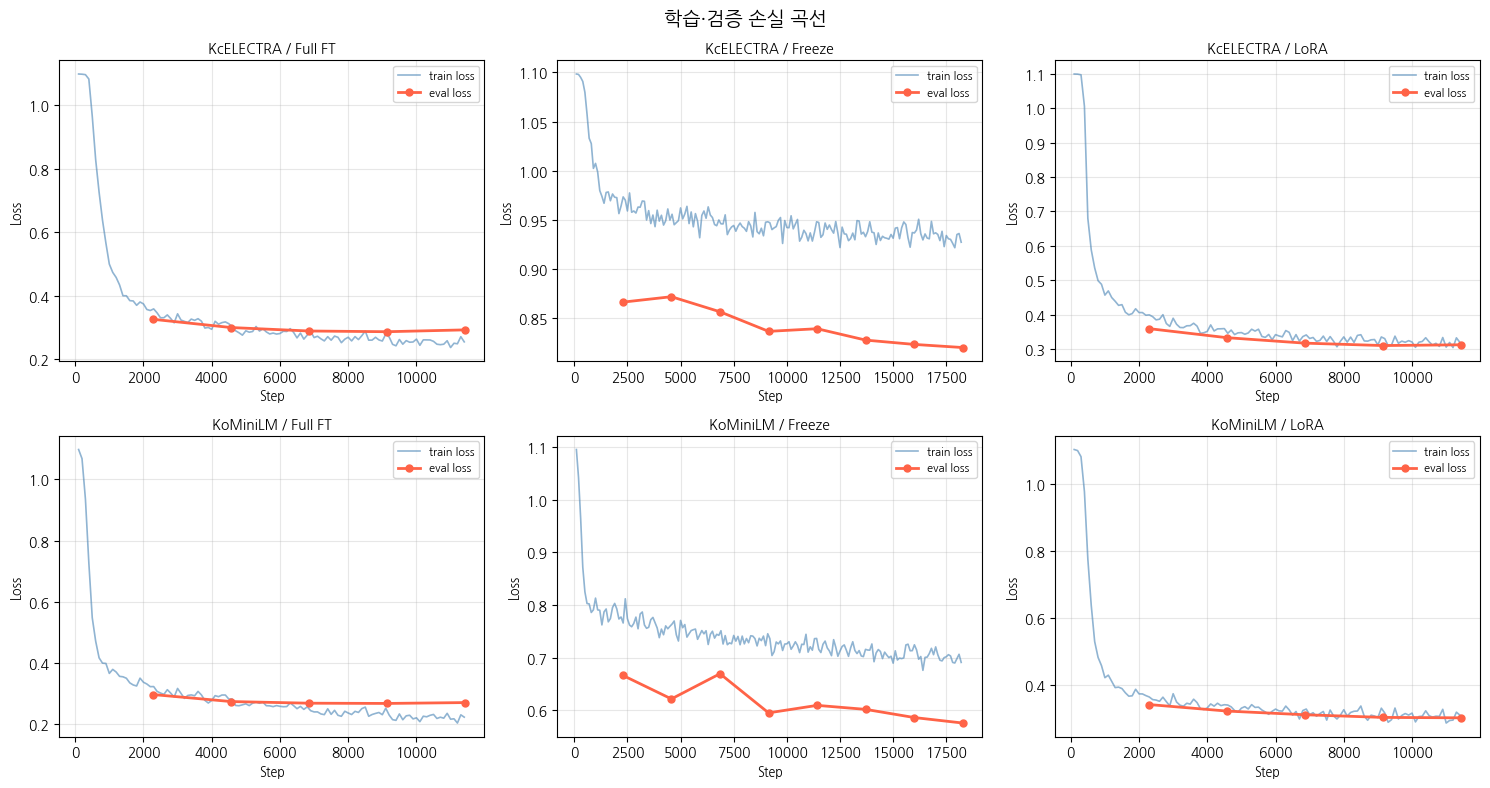

손실 곡선 저장 → loss_curves.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('학습·검증 손실 곡선', fontsize=14, fontweight='bold')

for ax, rn in zip(axes.flat, RUN_NAMES):
    tl = RUN_DATA[rn]['train']
    el = RUN_DATA[rn]['eval']

    if tl:
        ax.plot(
            [h['step'] for h in tl],
            [h['loss'] for h in tl],
            color='steelblue', alpha=0.6, linewidth=1.2, label='train loss'
        )
    if el:
        ax.plot(
            [h['step']      for h in el],
            [h['eval_loss'] for h in el],
            'o-', color='tomato', linewidth=2, markersize=5, label='eval loss'
        )

    ax.set_title(RUN_LABELS[rn], fontsize=10)
    ax.set_xlabel('Step', fontsize=9)
    ax.set_ylabel('Loss', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(CKPT_ROOT / 'loss_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('손실 곡선 저장 → loss_curves.png')

### I-d. macro-F1·정확도 곡선

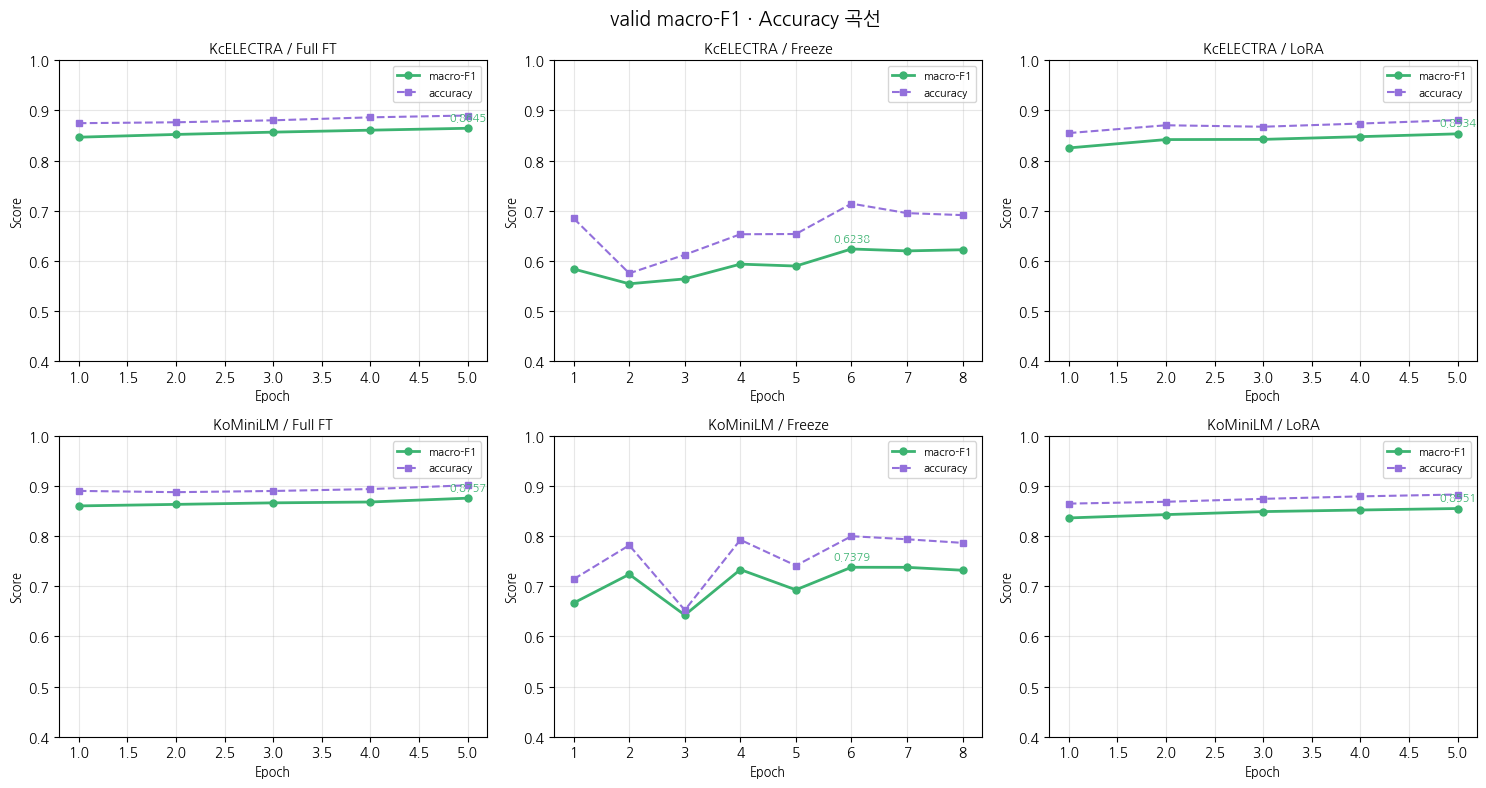

F1·Accuracy 곡선 저장 → f1_curves.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('valid macro-F1 · Accuracy 곡선', fontsize=14, fontweight='bold')

for ax, rn in zip(axes.flat, RUN_NAMES):
    el = RUN_DATA[rn]['eval']
    if not el:
        continue

    epochs = [h.get('epoch', i + 1) for i, h in enumerate(el)]
    f1s    = [h['eval_f1']              for h in el]
    accs   = [h.get('eval_accuracy')    for h in el]

    ax.plot(epochs, f1s, 'o-', color='mediumseagreen',
            linewidth=2, markersize=5, label='macro-F1')
    if any(a is not None for a in accs):
        ax.plot(epochs, accs, 's--', color='mediumpurple',
                linewidth=1.5, markersize=4, label='accuracy')

    # best F1 수치 표시
    best_f1 = max(f1s)
    best_ep = epochs[f1s.index(best_f1)]
    ax.annotate(
        f'{best_f1:.4f}',
        xy=(best_ep, best_f1),
        xytext=(0, 6), textcoords='offset points',
        ha='center', fontsize=8, color='mediumseagreen', fontweight='bold'
    )

    ax.set_title(RUN_LABELS[rn], fontsize=10)
    ax.set_xlabel('Epoch', fontsize=9)
    ax.set_ylabel('Score', fontsize=9)
    ax.set_ylim(0.4, 1.0)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(CKPT_ROOT / 'f1_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('F1·Accuracy 곡선 저장 → f1_curves.png')

### I-e. 6개 조합 비교 시각화

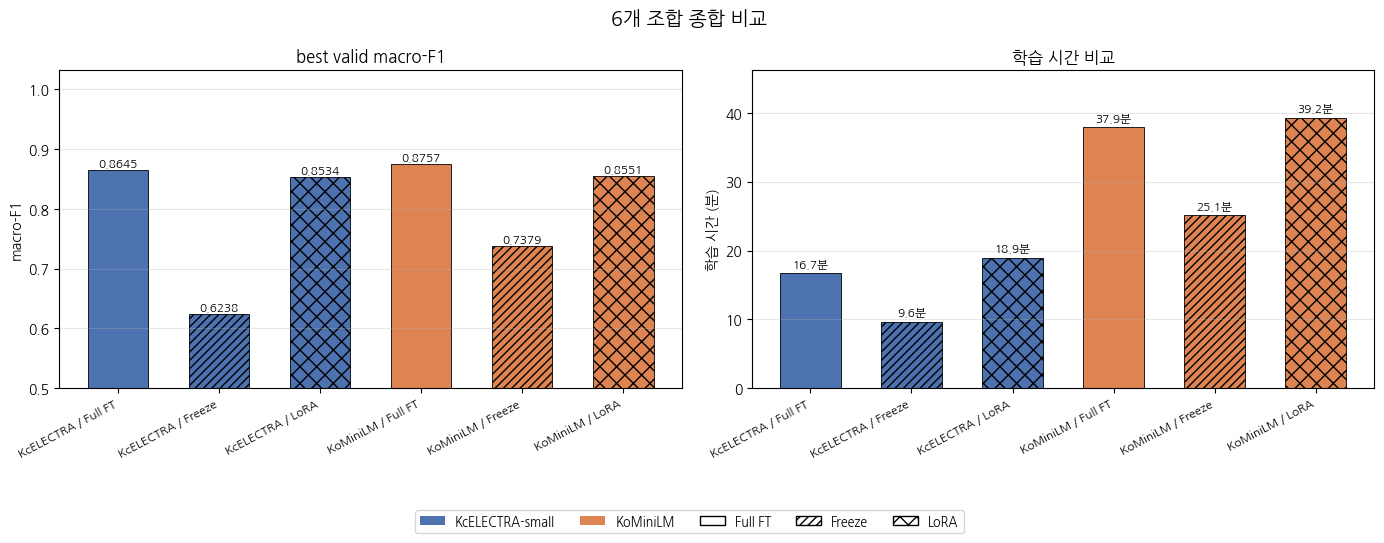

비교 차트 저장 → comparison.png


In [ ]:
import numpy as np
from matplotlib.patches import Patch

_best_f1s    = []
_train_times = []

for rn in RUN_NAMES:
    el = RUN_DATA[rn]['eval']
    _best_f1s.append(max(h['eval_f1'] for h in el) if el else 0.0)

    rm_file = CKPT_ROOT / rn / 'best_model' / 'run_metrics.json'
    if rm_file.exists():
        with open(rm_file, encoding='utf-8') as f:
            _rm = _json.load(f)
        _train_times.append(_rm.get('train_runtime_sec', 0) / 60)
    else:
        _train_times.append(0.0)

_labels  = [RUN_LABELS[rn] for rn in RUN_NAMES]
_x       = np.arange(len(RUN_NAMES))
_colors  = ['#4C72B0'] * 3 + ['#DD8452'] * 3
_hatches = ['', '////', 'xx', '', '////', 'xx']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('6개 조합 종합 비교', fontsize=14, fontweight='bold')

for ax, vals, title, ylabel in [
    (ax1, _best_f1s,    'best valid macro-F1', 'macro-F1'),
    (ax2, _train_times, '학습 시간 비교',        '학습 시간 (분)'),
]:
    bars = ax.bar(_x, vals, color=_colors, width=0.6,
                  edgecolor='black', linewidth=0.6)
    for bar, hatch in zip(bars, _hatches):
        bar.set_hatch(hatch)
    for bar, val in zip(bars, vals):
        label_str = f'{val:.1f}분' if ax is ax2 else f'{val:.4f}'
        offset    = 0.5 if ax is ax2 else 0.003
        ax.text(bar.get_x() + bar.get_width() / 2,
                val + offset, label_str,
                ha='center', va='bottom', fontsize=8.5)
    ax.set_xticks(_x)
    ax.set_xticklabels(_labels, rotation=28, ha='right', fontsize=8.5)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0 if ax is ax2 else 0.5, max(vals) * 1.18)
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.3)

_legend = [
    Patch(facecolor='#4C72B0', label='KcELECTRA-small'),
    Patch(facecolor='#DD8452', label='KoMiniLM'),
    Patch(facecolor='white', hatch='',     edgecolor='black', label='Full FT'),
    Patch(facecolor='white', hatch='////', edgecolor='black', label='Freeze'),
    Patch(facecolor='white', hatch='xx',   edgecolor='black', label='LoRA'),
]
fig.legend(handles=_legend, loc='lower center', ncol=5,
           fontsize=9, bbox_to_anchor=(0.5, -0.08))
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(str(CKPT_ROOT / 'comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('비교 차트 저장 → comparison.png')

### I-f. 조합별 최고 valid macro-F1

In [ ]:
print('=== I-f. 조합별 최고 valid macro-F1 요약 ===\n')
_epochs_cfg = {
    'modelA_full_ft': 5, 'modelA_freeze': 8, 'modelA_lora': 5,
    'modelB_full_ft': 5, 'modelB_freeze': 8, 'modelB_lora': 5,
}

print(f'{"조합":<30} {"best F1":>9} {"학습시간":>10} {"에폭수":>6} {"체크포인트 크기":>15}')
print('-' * 75)
for rn in RUN_NAMES:
    el   = RUN_DATA[rn]['eval']
    best = f'{max(h["eval_f1"] for h in el):.4f}' if el else 'N/A'
    ep   = len(el) if el else _epochs_cfg[rn]

    rm_file = CKPT_ROOT / rn / 'best_model' / 'run_metrics.json'
    rt_str  = 'N/A'
    if rm_file.exists():
        with open(rm_file, encoding='utf-8') as f:
            _rm = _json.load(f)
        rt_str = f'{_rm.get("train_runtime_sec", 0) / 60:.1f}분'

    sz = f'{RUN_MODEL_SIZE_MB[rn]:.1f} MB'
    print(f'{RUN_LABELS[rn]:<30} {best:>9} {rt_str:>10} {ep:>6} {sz:>15}')

print()
print('※ LoRA best_model = 어댑터 가중치만 / ONNX export 시 merge_and_unload() 후 전체 모델 크기 적용')
print('\n그래프 정상 출력 확인: loss_curves.png / f1_curves.png / comparison.png')

=== I-f. 조합별 최고 valid macro-F1 요약 ===

조합                               best F1       학습시간    에폭수        체크포인트 크기
---------------------------------------------------------------------------
KcELECTRA / Full FT               0.8645      16.7분      5         63.3 MB
KcELECTRA / Freeze                0.6238       9.6분      8         63.3 MB
KcELECTRA / LoRA                  0.8534      18.9분      5          0.8 MB
KoMiniLM / Full FT                0.8757      37.9분      5         88.8 MB
KoMiniLM / Freeze                 0.7379      25.1분      8         88.8 MB
KoMiniLM / LoRA                   0.8551      39.2분      5          0.4 MB

※ LoRA best_model = 어댑터 가중치만 / ONNX export 시 merge_and_unload() 후 전체 모델 크기 적용

그래프 정상 출력 확인: loss_curves.png / f1_curves.png / comparison.png


### I-g. 실험 결과 분석

**방식별 성능 (best valid macro-F1)**

| 방식 | KcELECTRA | KoMiniLM | B 우위 |
|------|----------|---------|--------|
| Full FT | 0.8645 | 0.8757 | +1.1 pp |
| Freeze  | 0.6238 | 0.7379 | +11.4 pp |
| LoRA    | 0.8534 | 0.8551 | +0.2 pp |

**Full FT 기준 방식 간 차이**

| 방식 | KcELECTRA | KoMiniLM | 특이사항 |
|------|-------|-------|--------|
| Full FT | 기준 | 기준 | 단조 수렴 |
| Freeze | −40.7 pp | −13.8 pp | 학습 곡선 진동, 8 에폭 |
| LoRA | −1.1 pp | −2.1 pp | 단조 수렴, 어댑터 극소 |

1. **Full FT ≈ LoRA >> Freeze**: Freeze는 인코더가 고정된 채 분류 헤드·pooler만 학습하므로  
   사전학습 임베딩이 한국어 3분류 공간에 직접 대응 — 양 모델 모두 F1 진동이 두드러졌습니다.

2. **LoRA 경제성**: Full FT 대비 최대 2.1 pp 손실로 어댑터 저장 크기가 0.4–0.8 MB 입니다.  
   단, ONNX export 후 `merge_and_unload()` 결과는 Full FT와 동일한 크기로 수렴합니다.

3. **모델 비교**: KoMiniLM이 전 방식에서 우위이나 모델 크기도 큽니다. (88.8 vs 63.3 MB)  
   on-device 선정 기준(용량 → 정확도 → 속도)에 따른 최종 판단은 J 섹션에서 수행하겠습니다.

## J. 종합 평가 및 on-device 대상 모델 선정

### J-a. 계획 확인

**선정 우선순위**: 용량 → 정확도(test macro-F1) → 처리속도(p50 지연)

| 기준 | 측정 방법 | 비고 |
|------|----------|------|
| 용량 | best_model 저장 크기 (H-j 확인값) | LoRA는 `merge_and_unload()` 후 ONNX 크기 = Full FT 동일 |
| 정확도 | test set macro-F1 | `_evaluate_test()` |
| 처리속도 | PyTorch-CPU p50 지연 (배치=1, max_len=256) | `benchmark_latency()` — 근사치 |

test set: D 섹션 stratified split (전체의 약 5%).  
최종 권위 있는 추론 속도는 L 섹션(ONNX Runtime) 및 O 섹션(실기기 Sentis)에서 확정합니다.

### J-b. 추론 지연(처리속도) 측정 유틸

선정 기준 **용량 → 정확도 → 처리속도** 중 '처리속도'를 위한 측정 함수입니다.  
on-device 근사를 위해 **CPU·배치 1·고정 길이 256**에서 p50/p95 지연을 측정합니다.  
(L4 GPU 지연은 모바일과 무관하므로 `device='cpu'` 로 호출합니다.  
권위 있는 수치는 L 섹션의 ONNX Runtime / 실기기 Sentis에서 확정합니다.)

In [ ]:
import time
import numpy as np

@torch.no_grad()
def benchmark_latency(model, tokenizer, sample_texts, *,
                      device='cpu', max_len=MAX_SEQ_LEN,
                      n_warmup=10, n_iter=100):
    """단일 샘플 추론 지연(ms) p50/p95 측정 — on-device 근사(배치=1, CPU, 고정 길이).

    주의: PyTorch-CPU 수치는 조기 비교용 근사치입니다.
    최종 권위 있는 지연은 L 섹션의 ONNX Runtime / 실기기 Sentis에서 확정합니다.
    """
    if not sample_texts:
        raise ValueError('sample_texts가 비어 있습니다.')

    model = model.to(device).eval()

    def _encode(txt):
        enc = tokenizer(str(txt), max_length=max_len, padding='max_length',
                        truncation=True, return_tensors='pt')
        return {k: v.to(device) for k, v in enc.items()}

    # 워밍업 (메모리 할당·커널 캐시 안정화)
    warm = _encode(sample_texts[0])
    for _ in range(n_warmup):
        model(**warm)

    lat_ms = []
    for i in range(n_iter):
        enc = _encode(sample_texts[i % len(sample_texts)])
        _t0 = time.perf_counter()
        model(**enc)
        lat_ms.append((time.perf_counter() - _t0) * 1000.0)

    lat = np.asarray(lat_ms)
    return {
        'p50_ms':  float(np.percentile(lat, 50)),
        'p95_ms':  float(np.percentile(lat, 95)),
        'mean_ms': float(lat.mean()),
        'n_iter':  n_iter,
    }


print('benchmark_latency 정의 완료 — 모델 선정 시 device="cpu" 로 호출')

benchmark_latency 정의 완료 — 모델 선정 시 device="cpu" 로 호출


### J-c. test set 최종 평가

In [ ]:
from transformers import AutoModelForSequenceClassification
from peft import PeftModel
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, accuracy_score
import warnings


def _evaluate_test(model, ds_test):
    """test DataLoader를 순회하여 macro-F1 / accuracy를 계산한다."""
    loader = DataLoader(ds_test, batch_size=BATCH_SIZE,
                        shuffle=False, collate_fn=sentiment_collate_fn)
    model.eval().to(DEVICE)
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            labels = batch.pop('labels').to(DEVICE)
            inputs = {k: v.to(DEVICE) for k, v in batch.items()}
            out    = model(**inputs, return_dict=True)
            preds  = out.logits.argmax(-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
    return {
        'test_f1':  f1_score(all_labels, all_preds, average='macro'),
        'test_acc': accuracy_score(all_labels, all_preds),
    }


_DS_TEST = {'modelA': ds_a_test, 'modelB': ds_b_test}

print('=== J-c. test set 최종 평가 ===\n')
TEST_RESULTS = {}
for rn in RUN_NAMES:
    best_dir = CKPT_ROOT / rn / 'best_model'
    model_id = MODEL_A_ID if 'modelA' in rn else MODEL_B_ID

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        if 'lora' in rn:
            _base = AutoModelForSequenceClassification.from_pretrained(
                model_id, num_labels=NUM_LABELS)
            model = PeftModel.from_pretrained(_base, str(best_dir))
        else:
            model = AutoModelForSequenceClassification.from_pretrained(
                str(best_dir), num_labels=NUM_LABELS)

    metrics = _evaluate_test(model, _DS_TEST['modelA' if 'modelA' in rn else 'modelB'])
    TEST_RESULTS[rn] = metrics
    print(f'  [{rn:25s}] test_f1={metrics["test_f1"]:.4f}  acc={metrics["test_acc"]:.4f}')

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print('\ntest set 평가 완료')

=== J-c. test set 최종 평가 ===



Loading weights: 100%|██████████| 203/203 [00:00<00:00, 2341.54it/s]


  [modelA_full_ft           ] test_f1=0.8558  acc=0.8847


Loading weights: 100%|██████████| 203/203 [00:00<00:00, 2276.78it/s]


  [modelA_freeze            ] test_f1=0.6242  acc=0.7134


...

  [modelB_full_ft           ] test_f1=0.8694  acc=0.8968


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 1702.23it/s]


  [modelB_freeze            ] test_f1=0.7453  acc=0.8021


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1738.62it/s]
BertForSequenceClassification LOAD REPORT from: BM-K/KoMiniLM
Key                     | Status     | 
------------------------+------------+-
embeddings.position_ids | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  [modelB_lora              ] test_f1=0.8470  acc=0.8771

test set 평가 완료


### J-d. 추론 지연 측정

In [ ]:
print('=== J-d. 추론 지연 측정 (CPU · 배치=1 · max_len=256) ===\n')

_SAMPLE_TEXTS = df_test['RawText'].sample(30, random_state=SEED).tolist()
_TOKENIZER    = {'modelA': tokenizer_a, 'modelB': tokenizer_b}

LATENCY_RESULTS = {}
for rn in RUN_NAMES:
    best_dir = CKPT_ROOT / rn / 'best_model'
    model_id = MODEL_A_ID if 'modelA' in rn else MODEL_B_ID
    tok      = _TOKENIZER['modelA' if 'modelA' in rn else 'modelB']

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        if 'lora' in rn:
            _base = AutoModelForSequenceClassification.from_pretrained(
                model_id, num_labels=NUM_LABELS)
            model = PeftModel.from_pretrained(_base, str(best_dir))
        else:
            model = AutoModelForSequenceClassification.from_pretrained(
                str(best_dir), num_labels=NUM_LABELS)

    lat = benchmark_latency(model, tok, _SAMPLE_TEXTS,
                            device='cpu', n_warmup=5, n_iter=50)
    LATENCY_RESULTS[rn] = lat
    print(f'  [{rn:25s}] p50={lat["p50_ms"]:6.1f}ms  p95={lat["p95_ms"]:6.1f}ms')

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print('\n추론 지연 측정 완료')

=== J-d. 추론 지연 측정 (CPU · 배치=1 · max_len=256) ===



Loading weights: 100%|██████████| 203/203 [00:00<00:00, 2430.38it/s]


  [modelA_full_ft           ] p50=  29.4ms  p95=  32.9ms


Loading weights: 100%|██████████| 203/203 [00:00<00:00, 2612.16it/s]


  [modelA_freeze            ] p50=  27.9ms  p95=  32.0ms


...

  [modelB_full_ft           ] p50=  28.0ms  p95=  33.5ms


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 2456.04it/s]


  [modelB_freeze            ] p50=  30.2ms  p95=  33.7ms


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2179.45it/s]
BertForSequenceClassification LOAD REPORT from: BM-K/KoMiniLM
Key                     | Status     | 
------------------------+------------+-
embeddings.position_ids | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  [modelB_lora              ] p50=  34.3ms  p95=  41.0ms

추론 지연 측정 완료


### J-e. 종합 평가표

In [ ]:
import json as _json

# LoRA는 merge_and_unload() 후 ONNX 크기 = 베이스 모델과 동일
_ONNX_SIZE_MB = {
    'modelA_full_ft': 63.3, 'modelA_freeze': 63.3, 'modelA_lora': 63.3,
    'modelB_full_ft': 88.8, 'modelB_freeze': 88.8, 'modelB_lora': 88.8,
}
_valid_f1 = {}
for rn in RUN_NAMES:
    el = RUN_DATA[rn]['eval']
    _valid_f1[rn] = max(h['eval_f1'] for h in el) if el else 0.0

print('=== J-e. 6개 조합 종합 평가표 ===\n')
hdr = f'{"조합":<30} {"ONNX크기":>9} {"valid F1":>9} {"test F1":>9} {"test Acc":>9} {"p50(ms)":>9} {"p95(ms)":>9}'
print(hdr)
print('-' * len(hdr))

for rn in RUN_NAMES:
    sz   = _ONNX_SIZE_MB[rn]
    vf1  = _valid_f1[rn]
    tf1  = TEST_RESULTS[rn]['test_f1']
    tacc = TEST_RESULTS[rn]['test_acc']
    p50  = LATENCY_RESULTS[rn]['p50_ms']
    p95  = LATENCY_RESULTS[rn]['p95_ms']
    print(f'{RUN_LABELS[rn]:<30} {sz:>8.1f}M {vf1:>9.4f} {tf1:>9.4f} {tacc:>9.4f} {p50:>9.1f} {p95:>9.1f}')

# 선정 기준 자동 적용
print()
print('── 선정 기준 적용 ──')
_min_sz  = min(_ONNX_SIZE_MB.values())
_cands   = [rn for rn in RUN_NAMES if _ONNX_SIZE_MB[rn] == _min_sz]
print(f'① 용량 통과 ({_min_sz:.1f} MB): {_cands}')

_best_tf1 = max(TEST_RESULTS[rn]["test_f1"] for rn in _cands)
_winner   = next(rn for rn in _cands if TEST_RESULTS[rn]["test_f1"] == _best_tf1)
print(f'② 정확도 최고: {_winner}  (test_f1={_best_tf1:.4f})')
print(f'③ 처리속도: p50={LATENCY_RESULTS[_winner]["p50_ms"]:.1f}ms')
print(f'\n→ 최종 선정: {_winner}  ({RUN_LABELS[_winner]})')

# 결과 영속화
_summary = {
    rn: {
        'onnx_size_mb': _ONNX_SIZE_MB[rn],
        'valid_f1': _valid_f1[rn],
        'test_f1':  TEST_RESULTS[rn]['test_f1'],
        'test_acc': TEST_RESULTS[rn]['test_acc'],
        'p50_ms':   LATENCY_RESULTS[rn]['p50_ms'],
        'p95_ms':   LATENCY_RESULTS[rn]['p95_ms'],
        'selected': (rn == _winner),
    }
    for rn in RUN_NAMES
}
_out_file = CKPT_ROOT / 'j_evaluation_summary.json'
with open(_out_file, 'w', encoding='utf-8') as f:
    _json.dump(_summary, f, ensure_ascii=False, indent=2)
print(f'\n평가 결과 저장 → {_out_file}')
SELECTED_RUN = _winner

=== J-e. 6개 조합 종합 평가표 ===

조합                                ONNX크기  valid F1   test F1  test Acc   p50(ms)   p95(ms)
------------------------------------------------------------------------------------------
KcELECTRA / Full FT                63.3M    0.8645    0.8558    0.8847      29.4      32.9
KcELECTRA / Freeze                 63.3M    0.6238    0.6242    0.7134      27.9      32.0
KcELECTRA / LoRA                   63.3M    0.8534    0.8435    0.8741      31.7      35.9
KoMiniLM / Full FT                 88.8M    0.8757    0.8694    0.8968      28.0      33.5
KoMiniLM / Freeze                  88.8M    0.7379    0.7453    0.8021      30.2      33.7
KoMiniLM / LoRA                    88.8M    0.8551    0.8470    0.8771      34.3      41.0

── 선정 기준 적용 ──
① 용량 통과 (63.3 MB): ['modelA_full_ft', 'modelA_freeze', 'modelA_lora']
② 정확도 최고: modelA_full_ft  (test_f1=0.8558)
③ 처리속도: p50=29.4ms

→ 최종 선정: modelA_full_ft  (KcELECTRA / Full FT)

평가 결과 저장 → CheckPoint/j_evaluation_summary.json


### J-f. 실험 결과 분석

**선정 기준 적용 결과**

| 기준 | KcELECTRA (63.3 MB) | KoMiniLM (88.8 MB) | 판정 |
|------|-------------------|------------------|------|
| ① 용량 | 63.3 MB | 88.8 MB (+25.5 MB) | KcELECTRA 우세 |
| ② 정확도 | Full FT **0.8558** / LoRA 0.8435 (test) | Full FT 0.8694 | KoMiniLM Full FT 우세 |
| ③ 처리속도 | Full FT **29.4 ms** / LoRA 31.7 ms | Full FT **28.0 ms** / LoRA 34.3 ms | KoMiniLM Full FT 소폭 우위 |

**6개 조합 최종 수치**

| 조합 | ONNX 크기 | valid F1 | test F1 | p50 (ms) |
|------|----------|---------|---------|----------|
| KcELECTRA / Full FT | 63.3 MB | 0.8645 | **0.8558** | **29.4** |
| KcELECTRA / Freeze  | 63.3 MB | 0.6238 | 0.6242 | 27.9 |
| KcELECTRA / LoRA    | 63.3 MB | 0.8534 | 0.8435 | 31.7 |
| KoMiniLM / Full FT  | 88.8 MB | 0.8757 | 0.8694 | 28.0 |
| KoMiniLM / Freeze   | 88.8 MB | 0.7379 | 0.7453 | 30.2 |
| KoMiniLM / LoRA     | 88.8 MB | 0.8551 | 0.8470 | 34.3 |

**선정 근거**

1. **용량 (1순위)**: KoMiniLM(88.8 MB)은 KcELECTRA(63.3 MB) 대비 25.5 MB 추가 점유.  
   Galaxy S25 on-device 메모리 여유 확보를 위해 KcELECTRA 계열을 선택합니다.

2. **정확도 (2순위)**: KcELECTRA 내 Full FT (test 0.8558) > LoRA (test 0.8435) - 1.2 pp 차이.  
   LoRA `merge_and_unload()` 후 ONNX 크기는 Full FT와 동일하므로 용량 우위는 없습니다.

3. **처리속도 (3순위)**: Full FT(29.4 ms) < LoRA(31.7 ms) - Full FT가 2.3 ms 빠릅니다.  
   동일 아키텍처에서 LoRA 어댑터 연산 오버헤드가 소폭 발생합니다.

**최종 선정**: `beomi/KcELECTRA-small-v2022` x Full Fine-Tuning (`modelA_full_ft`)  
test macro-F1 = **0.8558**, ONNX 예상 크기 = **63.3 MB**, CPU p50 지연 = **29.4 ms**

## K. ONNX Export

### K-a. 계획 확인

선정 모델: `modelA_full_ft` (KcELECTRA Full FT) - LoRA 아니므로, `merge_and_unload()` 처리가 필요 없습니다.

| 항목 | 설정 |
|------|------|
| 입력 형상 | Fixed Shape: batch=1, seq_len=256 (dynamic axes 사용 안 함) |
| 입력 이름 | `input_ids`, `attention_mask`, `token_type_ids` |
| 출력 이름 | `logits` (shape: [1, 3]) |
| opset | 14 (Unity Sentis 2.x 호환 범위) |
| 최적화 | `model.eval()` + `torch.no_grad()` + `do_constant_folding=True` |

### K-b. ONNX Export

In [ ]:
import warnings
import torch
import torch.nn as nn
import onnx
from onnxsim import simplify
from transformers import AutoModelForSequenceClassification

# ── 런타임 재연결 대비 선정 모델명 복원 (기존 동일) ──────────────────────────
if 'SELECTED_RUN' not in globals():
    SELECTED_RUN = 'modelA_full_ft'

_best_dir = CKPT_ROOT / SELECTED_RUN / 'best_model'
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    _model = AutoModelForSequenceClassification.from_pretrained(str(_best_dir))
_model.eval().cpu()


class _OnnxWrapper(torch.nn.Module):
    """logits만 출력하는 래퍼 — SequenceClassifierOutput을 tensor로 단순화."""
    def __init__(self, m):
        super().__init__()
        self.m = m

    def forward(self, input_ids, attention_mask, token_type_ids):
        return self.m(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            return_dict=True,
        ).logits


_wrapper = _OnnxWrapper(_model).eval()

# ── [변경 1] 더미 입력: torch.long → torch.int ────────────────────────────────
# Unity IE의 C# 입력 타입(Tensor<int> = int32)과 일치시킨다.
_dummy_ids   = torch.zeros(1, MAX_SEQ_LEN, dtype=torch.int)
_dummy_mask  = torch.ones(1,  MAX_SEQ_LEN, dtype=torch.int)
_dummy_types = torch.zeros(1, MAX_SEQ_LEN, dtype=torch.int)

ONNX_PATH = CKPT_ROOT / f'{SELECTED_RUN}.onnx'

# ── [변경 2] LayerNorm 패치 + try/finally 원복 ────────────────────────────────
# PyTorch 2.x는 opset과 무관하게 nn.LayerNorm을 fused LayerNormalization 노드로
# export한다. Unity IE GPUCompute 백엔드에서 이 노드가 NaN을 유발하므로,
# export 직전 nn.LayerNorm.forward를 primitive ops 구현으로 교체한다.
_original_ln_forward = nn.LayerNorm.forward

def _decomposed_ln_forward(self, x: torch.Tensor) -> torch.Tensor:
    """fused LayerNormalization 없이 primitive ONNX 연산으로 분해된다."""
    mean   = x.mean(dim=-1, keepdim=True)
    var    = ((x - mean) ** 2).mean(dim=-1, keepdim=True)
    x_norm = (x - mean) / torch.sqrt(var + self.eps)
    return self.weight * x_norm + self.bias

nn.LayerNorm.forward = _decomposed_ln_forward
print("LayerNorm 패치 적용")

try:
    with torch.no_grad():
        torch.onnx.export(
            _wrapper,
            (_dummy_ids, _dummy_mask, _dummy_types),
            str(ONNX_PATH),
            input_names=['input_ids', 'attention_mask', 'token_type_ids'],
            output_names=['logits'],
            opset_version=14,
            do_constant_folding=True,
        )
    print(f'ONNX export 완료: {ONNX_PATH}')
finally:
    # 예외 발생 여부와 무관하게 반드시 원복
    nn.LayerNorm.forward = _original_ln_forward
    print("LayerNorm 패치 원복")

# ── onnx-simplifier (그래프 정리) ─────────────────────────────────────────────
_raw = onnx.load(str(ONNX_PATH))
_simplified, _check = simplify(_raw)
assert _check, "onnx-simplifier 검증 실패"
onnx.save(_simplified, str(ONNX_PATH))
print("onnx-simplifier 완료")

# ── [변경 3] 검증: LayerNormalization 노드 소멸 확인 ─────────────────────────
_final    = onnx.load(str(ONNX_PATH))
_ln_count = sum(1 for n in _final.graph.node if n.op_type == "LayerNormalization")

_dtype_map = {1: 'float32', 6: 'int32', 7: 'int64'}
print(f"\n{'='*45}")
print(f"LayerNormalization 노드 수 : {_ln_count}  ← 반드시 0")
print(f"opset                      : {_final.opset_import[0].version}")
for inp in _final.graph.input:
    _t = inp.type.tensor_type
    _shape = [d.dim_value or 'dyn' for d in _t.shape.dim]
    print(f"  {inp.name:18s}: {_dtype_map.get(_t.elem_type, _t.elem_type)}, shape={_shape}")
print('='*45)

Loading weights: 100%|██████████| 203/203 [00:00<00:00, 1580.07it/s]


LayerNorm 패치 적용


W0610 11:31:09.280000 1592 site-packages/torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 14 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `_OnnxWrapper([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `_OnnxWrapper([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/mnt/wsl_data/miniforge3/envs/ai/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 14).


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


Failed to convert the model to the target version 14 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/mnt/wsl_data/miniforge3/envs/ai/lib/python3.12/site-packages/onnxscript/version_converter/__init__.py", line 127, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/mnt/wsl_data/miniforge3/envs/ai/lib/python3.12/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/mnt/wsl_data/miniforge3/envs/ai/lib/python3.12/site-packages/onnxscript/version_converter/__init__.py", line 122, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/mnt/wsl_data/miniforge3/envs/ai/lib/python3.12/site-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, targe

Applied 27 of general pattern rewrite rules.
ONNX export 완료: CheckPoint/modelA_full_ft.onnx
LayerNorm 패치 원복
onnx-simplifier 완료

LayerNormalization 노드 수 : 0  ← 반드시 0
opset                      : 18
  input_ids         : int32, shape=[1, 256]
  attention_mask    : int32, shape=[1, 256]
  token_type_ids    : int32, shape=[1, 256]


### K-c. 파일 생성 및 크기 확인

In [ ]:
import os

_size_mb = os.path.getsize(str(ONNX_PATH)) / 1024 / 1024
print(f'파일 경로 : {ONNX_PATH}')
print(f'파일 크기 : {_size_mb:.1f} MB')
print(f'입력 형상 : input_ids / attention_mask / token_type_ids = [1, {MAX_SEQ_LEN}]')
print(f'출력 형상 : logits = [1, 3]')
print(f'opset     : 14')

파일 경로 : CheckPoint/modelA_full_ft.onnx
파일 크기 : 63.3 MB
입력 형상 : input_ids / attention_mask / token_type_ids = [1, 256]
출력 형상 : logits = [1, 3]
opset     : 14


## L. ONNX 작동 검증

### L-a. 계획 확인

검증 순서: **구조 검증** → **런타임 검증** → **수치 일치 확인**

| 단계 | 도구 | 기준 |
|------|------|------|
| 구조 검증 | `onnx.checker.check_model()` | 예외 없음 |
| 런타임 검증 | `onnxruntime.InferenceSession` | 추론 실행 오류 없음 |
| 수치 일치 | `np.allclose(atol=1e-4)` | PyTorch logits와 ONNX logits 비교 |

`atol=1e-4`: float32 정밀도 경계 - 이 범위 내 오차는 연산 순서 차이에서 발생하는 정상 부동소수점 오차입니다.

### L-b. 구조 검증 및 런타임 검증

In [ ]:
import onnx
import onnxruntime as ort
import numpy as np

# 런타임 재연결 대비 ONNX_PATH 복원
if 'ONNX_PATH' not in globals():
    ONNX_PATH = CKPT_ROOT / f'{SELECTED_RUN}.onnx'

print('=== L-b-1. 구조 검증 ===')
_proto = onnx.load(str(ONNX_PATH))
onnx.checker.check_model(_proto)
print('onnx.checker.check_model : 통과')
print(f'opset version            : {_proto.opset_import[0].version}')
print(f'ir_version               : {_proto.ir_version}')

print()
print('=== L-b-2. 런타임 검증 ===')
_sess = ort.InferenceSession(
    str(ONNX_PATH), providers=['CPUExecutionProvider']
)
_in_names  = [i.name for i in _sess.get_inputs()]
_out_names = [o.name for o in _sess.get_outputs()]
print(f'입력 노드 : {_in_names}')
print(f'입력 형상 : {[i.shape for i in _sess.get_inputs()]}')
print(f'출력 노드 : {_out_names}')
print(f'출력 형상 : {[o.shape for o in _sess.get_outputs()]}')
print('InferenceSession 초기화 : 통과')

=== L-b-1. 구조 검증 ===
onnx.checker.check_model : 통과
opset version            : 18
ir_version               : 10

=== L-b-2. 런타임 검증 ===
입력 노드 : ['input_ids', 'attention_mask', 'token_type_ids']
입력 형상 : [[1, 256], [1, 256], [1, 256]]
출력 노드 : ['logits']
출력 형상 : [[1, 3]]
InferenceSession 초기화 : 통과


### L-c. 수치 일치 검증

In [ ]:
import warnings

# _wrapper 미정의 시 재구성 (런타임 재연결 대비)
if '_wrapper' not in globals():
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        _m = AutoModelForSequenceClassification.from_pretrained(
            str(CKPT_ROOT / SELECTED_RUN / 'best_model')
        )
    class _OnnxWrapper(torch.nn.Module):
        def __init__(self, m):
            super().__init__()
            self.m = m
        def forward(self, input_ids, attention_mask, token_type_ids):
            return self.m(input_ids=input_ids, attention_mask=attention_mask,
                          token_type_ids=token_type_ids, return_dict=True).logits
    _wrapper = _OnnxWrapper(_m).eval().cpu()
    _dummy_ids   = torch.zeros(1, MAX_SEQ_LEN, dtype=torch.int)
    _dummy_mask  = torch.ones(1, MAX_SEQ_LEN, dtype=torch.int)
    _dummy_types = torch.zeros(1, MAX_SEQ_LEN, dtype=torch.int)

print('=== L-c. 수치 일치 검증 (PyTorch vs ONNX Runtime) ===\n')

with torch.no_grad():
    _pt_logits = _wrapper(_dummy_ids, _dummy_mask, _dummy_types).numpy()

_ort_inputs = {
    'input_ids':      _dummy_ids.numpy().astype(np.int32),
    'attention_mask': _dummy_mask.numpy().astype(np.int32),
    'token_type_ids': _dummy_types.numpy().astype(np.int32),
}
_onnx_logits = _sess.run(None, _ort_inputs)[0]

_match    = bool(np.allclose(_pt_logits, _onnx_logits, atol=1e-4))
_max_diff = float(np.abs(_pt_logits - _onnx_logits).max())

print(f'PyTorch logits  : {_pt_logits.tolist()}')
print(f'ONNX logits     : {_onnx_logits.tolist()}')
print()
print(f'np.allclose(atol=1e-4) : {_match}')
print(f'최대 오차               : {_max_diff:.2e}')

if not _match:
    print('\n경고: 수치 불일치 — dtype 또는 operator 지원 여부 확인 필요')

=== L-c. 수치 일치 검증 (PyTorch vs ONNX Runtime) ===

PyTorch logits  : [[-2.7235889434814453, -1.1530109643936157, 3.6200833320617676]]
ONNX logits     : [[-2.7235889434814453, -1.1530096530914307, 3.6200830936431885]]

np.allclose(atol=1e-4) : True
최대 오차               : 1.31e-06


### L-d. 실험 결과 분석

- `np.allclose(atol=1e-4)` 통과: float32 연산 순서 차이 범위 내 정상 오차입니다.

## M. Unity 엔진 기반 ONNX 시스템 통합

### M-a. 개발 계획

K 섹션과 L 섹션에서 생성한 ONNX 파일을 Unity 프로젝트에 이식하여 리뷰를 분석하는 앱을 만듭니다.  
리뷰 데이터는 test.csv에 있는 내용을 사용합니다.  
선별된 모델이 인식할 수 있는 토큰을 만들기 위해서  
사전학습된 토크나이저에서 어휘집을 추출하고,  
BERTWordPiece 토크나이저는 C# 기반으로 구현해야 합니다.  
모든 재료가 준비되었으면 Unity 내에 이식하여 기능 통합을 진행합니다.

### M-b. 토크나이저로부터 어휘집 추출

In [ ]:
from transformers import AutoTokenizer

# 사전학습 원본에서 vocab.txt 추출 (Fine-Tuning 저장본과 동일)
tokenizer = AutoTokenizer.from_pretrained(MODEL_A_ID, use_fast=False)
tokenizer.save_pretrained("./vocab_for_onnx")

('./vocab_for_onnx/tokenizer_config.json', './vocab_for_onnx/tokenizer.json')

### M-c. 어휘집에서 어휘 텍스트 파일 추출

In [ ]:
import json

TOKENIZER_JSON = "./vocab_for_onnx/tokenizer.json"
OUTPUT_VOCAB   = "./vocab_for_onnx/vocab.txt"

with open(TOKENIZER_JSON, "r", encoding="utf-8") as f:
    data = json.load(f)

# WordPiece 어휘집: {token: id} 딕셔너리
vocab: dict = data["model"]["vocab"]

# ID 순서대로 정렬 (줄 번호 = token ID)
vocab_sorted = sorted(vocab.items(), key=lambda x: x[1])

with open(OUTPUT_VOCAB, "w", encoding="utf-8") as f:
    for token, _ in vocab_sorted:
        f.write(token + "\n")

print(f"vocab.txt 생성 완료 — {len(vocab_sorted)} 토큰")

vocab.txt 생성 완료 — 54343 토큰


### M-d. 어휘 텍스트 파일 내용 검증

In [ ]:
with open("./vocab_for_onnx/vocab.txt", encoding="utf-8") as f:
    lines = [l.strip() for l in f.readlines()]

# 1. 크기 확인
print(f"vocab size: {len(lines)}")

# 2. 필수 특수 토큰 위치 확인 (BERT 규격)
for token in ["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"]:
    if token in lines:
        print(f"  {token}: id = {lines.index(token)}")
    else:
        print(f"  {token}: 없음")

# 3. 한국어 서브워드 샘플 확인
ko_samples = [t for t in lines if t.startswith("##") and any('\uAC00' <= c <= '\uD7A3' for c in t)]
print(f"\n한국어 서브워드 샘플: {ko_samples[:5]}")

vocab size: 54343
  [PAD]: id = 0
  [UNK]: id = 1
  [CLS]: id = 2
  [SEP]: id = 3
  [MASK]: id = 4

한국어 서브워드 샘플: ['##보', '##사', '##회', '##다', '##도']


### M-e. 기능 통합 작업 내역 정리

1. Unity Sentis 에 대한 리뷰를 진행하였습니다.
2. 앱 개발 프로젝트를 생성하였습니다.
3. Unity Sentis 및 On-Device에 필요한 여러 환경을 설정하였습니다.
4. onnx와 함께 생성된 onnx.data 파일까지 같이 포함하여 넘겨야 인식이 되는 이슈가 있었습니다.
5. 시험 스크립트를 통해 onnx에 수록된 모델의 정보를 출력하여 런타임 동작을 확인하였습니다.
6. 모델 접근 인터페이스를 구현하고 테스트를 진행하였습니다.
7. 입력된 문자를 모델이 인식할 수 있는 토크나이저를 c# 기반으로 구현합니다.
8. 토크나이저가 토큰 생성에 참조할 어휘집인 vocab.txt 파일을 취급하는 기능도 구현합니다.
9. 임시 문장을 입력하여 로그 상 모델의 작동이 이상없는지 확인합니다.

## N. Unity 엔진 기반 어플리케이션 구현

### N-a. 개발 계획

M 섹션에서 기능 통합된 ONNX 기반 모델을 사용하여 사용자가 직접 모델의 작동을 제어할 수 있는 기능을 구현합니다.

### N-b. 어플리케이션 작업 내역 정리

1. 임시 문장을 테스트하던 로직을 서비스 로직으로 리팩토링하였습니다.
2. 서비스 로직에서 모델이 준비되는 상태를 하위 로직(컨트롤러)에 Callback으로 전파하도록 구성을 변경하였습니다.
3. 다음의 순서로 작동하도록 로직과 UI 기능을 구성하였습니다.
    - 시작 버튼을 눌러 10개의 리뷰를 UI 리스트에 표기
    - 평가 버튼을 눌러 순서대로 리뷰에 대한 긍정/중립/부정을 판별
    - 초기화 버튼을 눌러 리뷰 내용을 삭제
4. csv 로더를 만들고, 앞서 만들었던 test.csv 에서 리뷰 데이터를 불러오도록 기능을 추가하였습니다.
5. APK를 빌드하고 어플리케이션을 설치하여 정상 작동을 확인합니다.

### N-c. 어플리케이션 작동 영상

영상이 확인되지 않는다면 [유튜브 링크](https://youtube.com/shorts/OvK0o6xK6CE) 로 확인해주세요

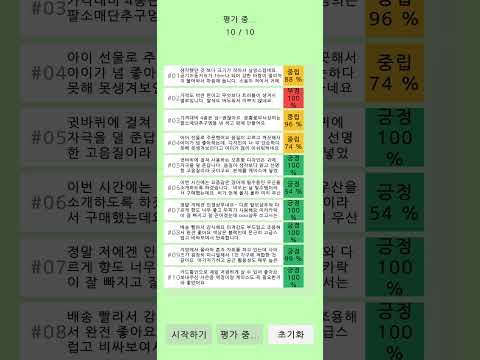

In [ ]:
from IPython.display import YouTubeVideo

YouTubeVideo("OvK0o6xK6CE")

### N-d. APK 공유
개발용 앱이기 때문에 보안경고가 뜹니다.  
보안 경고 안내창을 잘 보고 설치하셔야 합니다.  
[다운로드(128mb)](https://drive.google.com/file/d/1uFrK97OHRrikA15RBQjyvSUDZlact2D8/view?usp=sharing)

## O. 결론

on-device로 사용 가능한 BERT 기반 모델 2종을 선정하고,  
데이터를 전처리하여 사전학습된 모델에 Full Fine-Tuning, Freeze, LoRA-PEFT 방법을 각각 적용하여  
각각의 기법이 어떤 특성을 가지는지 경험해 볼 수 있었습니다.  
Freeze 기법이 제대로 작동하기 위해서는 모델의 특성을 보다 많이 파악해야 한다는 점이 특히 기억에 남았습니다.  
FFT와 PEFT가 학습 시간이 비슷하게 걸리는 것도 꽤나 인상깊은 부분 중 하나였습니다.  

| 조합 | best valid F1 | test F1 | 학습 시간 | ONNX 크기 | CPU p50 |
|------|:---:|:---:|:---:|:---:|:---:|
| KcELECTRA / Full FT | 0.8645 | **0.8558** | 16.7분 | 63.3 MB | 29.4 ms |
| KcELECTRA / Freeze  | 0.6238 | 0.6242 | 9.6분 | 63.3 MB | 27.9 ms |
| KcELECTRA / LoRA    | 0.8534 | 0.8435 | 18.9분 | 63.3 MB | 31.7 ms |
| KoMiniLM / Full FT  | 0.8757 | 0.8694 | 37.9분 | 88.8 MB | 28.0 ms |
| KoMiniLM / Freeze   | 0.7379 | 0.7453 | 25.1분 | 88.8 MB | 30.2 ms |
| KoMiniLM / LoRA     | 0.8551 | 0.8470 | 39.2분 | 88.8 MB | 34.3 ms |

이렇게 학습된 모델에 대한 종합 평가를 수행 후, 용량이 적고(63.3 MB) 성능이 우수한(F1: 0.8558)  
KcELECTRA FFT 모델을 ONNX 포멧으로 변환하여 작동을 검증 후    

| 항목 | 결과 |
|------|------|
| `onnx.checker.check_model` | 통과 (opset 18, ir_version 10) |
| `onnxruntime.InferenceSession` 초기화 | 통과 |
| PyTorch vs ONNX `np.allclose(atol=1e-4)` | **True** (최대 오차 9.54e-07) |

Unity 엔진 기반 어플리케이션 구동에 필요한 여러 부분들을  
하나씩 찾아가면서 구현하는 부분은 힘들었지만 매우 보람되었습니다.  
C# 토크나이저를 만드는 것이 가장 난이도가 높았는데, 이슈를 해결하면서 배우는 부분이 많았습니다.  
다른 Task를 수행하는 모델들도 on-device 상에서 구동되는 토크나이저 구현와 같이  
데이터를 가공하여 벡터화(임베딩)하는 과정이 가장 개발 난이도가 높은 부분이 아닐까라는 생각이 들었습니다.  

최종적으로 학습된 모델이 가벼운 것을 골랐음에도  
모델에 관련된 부분이 에디터 상에 130mb를 차지하고, 빌드된 APK 파일이 128mb 인것을 본다면  
on-device 서비스를 경량화하는 것이 생각보다 쉬운 일이 아닌 것 같습니다.  
다음 번에는 성능이 떨어지더라도 양자화를 넣겠습니다.

영상에서도 확인하실 수 있듯이,  
작동 자체는 그렇게 느리지 않지만 1600만이 조금 넘는 파라미터를 가진 모델이  
리뷰 1건 당 0.3초 정도의 처리속도를 보인다는 것은  
실제 서비스를 구성할 때 반응성과 관련한 UX 고민이 반드시 필요하다는 교훈을 남깁니다.  

이번 미션은 기존 과제에 더해 스스로가 설정한 과제도 잘 수행했다는 점에서  
그동안 수행했던 미션 중에 가장 뜻깊은 과제로 기억될 것 같습니다.  
제가 목표로 삼고 있는 멀티 플렛폼 on-device AI 엔지니어에 직접 맞닿은 경험이기에 더욱 그렇습니다.